# Paper KNN Graph — Embedding → Network → Analysis → Viz

**Pipeline:** SPECTER2 embeddings → Top-K cosine-similarity graph → Leiden communities → cross-country / structural analysis → interactive visualisation.

**Outputs** → `output/graph/`

| File | Description |
|------|-------------|
| `edges.parquet` | Edge list with sim + node attributes |
| `nodes.parquet` | Node attributes + graph metrics |
| `communities.parquet` | Node → community mapping |
| `summary.json` | Key metrics digest |
| `figs/*.png / .html` | Figures |

In [3]:
# Required packages (uncomment if needed):
#   pip install faiss-cpu leidenalg python-igraph networkx pandas numpy
#               scipy pyarrow plotly matplotlib tqdm scikit-learn

import os, json, warnings, time
from pathlib import Path
from typing import Optional, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ─
#
# Required packages (uncomment if needed):
#   pip install faiss-cpu leidenalg python-igraph networkx pandas numpy
#               scipy pyarrow plotly matplotlib tqdm scikit-learn

import os, json, warnings, time
from pathlib import Path
from typing import Optional, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ─
#
# Required packages (uncomment if needed):
#   pip install faiss-cpu leidenalg python-igraph networkx pandas numpy
#               scipy pyarrow plotly matplotlib tqdm scikit-learn

import os, json, warnings, time
from pathlib import Path
from typing import Optional, Literal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ── Reproducibility ─
SEED = 42
np.random.seed(SEED)

# ── Paths ─
SEED = 42
np.random.seed(SEED)

# ── Paths ─
DATA_CSV        = "data/dataCleanSCIE.csv"
PAPER_TOPICS    = "output/cluster_results/paper_topics.csv"
EMBEDDINGS_NPY  = "output/cluster_results/specter2_embeddings_cache.npy"
OUTPUT_DIR      = Path("output/graph")
FIGS_DIR        = OUTPUT_DIR / "figs"

# ── Graph hyper-parameters ─
DATA_CSV        = "data/dataCleanSCIE.csv"
PAPER_TOPICS    = "output/cluster_results/paper_topics.csv"
EMBEDDINGS_NPY  = "output/cluster_results/specter2_embeddings_cache.npy"
OUTPUT_DIR      = Path("output/graph")
FIGS_DIR        = OUTPUT_DIR / "figs"

# ── Graph hyper-parameters ─
K               = 30        # Top-K neighbours per node
TAU             = None        # similarity threshold (None = keep all K)
MUTUAL          = True        # mutual kNN (undirected)
METHOD          = "faiss_exact"  # faiss_exact | faiss_ivf | hnswlib

# ── Community detection ─
K               = 30        # Top-K neighbours per node
TAU             = None        # similarity threshold (None = keep all K)
MUTUAL          = True        # mutual kNN (undirected)
METHOD          = "faiss_exact"  # faiss_exact | faiss_ivf | hnswlib

# ── Community detection ─
LEIDEN_RES      = 1.0

# ── Visualisation / sampling ─
LEIDEN_RES      = 1.0

# ── Visualisation / sampling ─
SAMPLING_SIZE   = 5000
BETWEENNESS_K   = 5000
ROLLING_WINDOW  = 5

# ── Country mapping ─
SAMPLING_SIZE   = 5000
BETWEENNESS_K   = 5000
ROLLING_WINDOW  = 5

# ── Country mapping ─
CN_LABELS = {"China", "china", "CN", "CHINA", "Peoples R China"}
US_LABELS = {"United States", "united states", "US", "USA",
             "United States of America"}

# ── Create output dirs ─
CN_LABELS = {"China", "china", "CN", "CHINA", "Peoples R China"}
US_LABELS = {"United States", "united states", "US", "USA",
             "United States of America"}

# ── Create output dirs ─
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

print(f"\u2705 Config loaded | K={K}, tau={TAU}, mutual={MUTUAL}, method={METHOD}")
print(f"   Output \u2192 {OUTPUT_DIR.resolve()}")


✅ Config loaded | K=30, tau=None, mutual=True, method=faiss_exact
   Output → /Users/luoyiti/Project/catch-up/output/graph


/Users/luoyiti/Project/catch-up/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## §1  Load Data & Align Embeddings

Read CSV + embeddings `.npy`, align rows, standardise country/year/topic columns.

In [4]:
# §1  Load & Align
# ══════════════════════════════════════════════════════════════════════

def load_and_align(data_csv, emb_npy, paper_topics_csv=None):
    """
    Load CSV + embeddings; align rows; standardise columns.
    Returns: df (DataFrame), emb (ndarray L2-normed)
    """
    df_raw = pd.read_csv(data_csv, low_memory=False)
    print(f"Raw CSV rows: {len(df_raw):,}  cols: {df_raw.shape[1]}")

    col_map = {"TI": "title", "AB": "abstract", "PY": "year",
               "TC": "citation", "UT": "paper_id"}
    present = {k: v for k, v in col_map.items() if k in df_raw.columns}
    df = df_raw.rename(columns=present).copy()

    if "paper_id" not in df.columns:
        df["paper_id"] = [f"paper_{i}" for i in range(len(df))]

    df["title"]    = df["title"].fillna("") if "title" in df.columns else ""
    df["abstract"] = df["abstract"].fillna("") if "abstract" in df.columns else ""
    df["text"] = (df["title"].astype(str).str.strip() + ". "
                  + df["abstract"].astype(str).str.strip())
    df = df[df["text"].str.len() >= 20].reset_index(drop=True)
    print(f"After text filter: {len(df):,}")

    # Country mapping
    def _map_c(c):
        if c in CN_LABELS: return "CN"
        if c in US_LABELS: return "US"
        return "OTHER"

    if "country" in df.columns:
        df["country2"] = df["country"].apply(_map_c)
    elif "country_code" in df.columns:
        df["country2"] = df["country_code"].apply(_map_c)
    else:
        df["country2"] = "OTHER"
        print("Warning: No country column found")

    # Year
    if "year" in df.columns:
        df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    else:
        df["year"] = pd.NA

    # Topic (merge from paper_topics.csv if needed)
    topic_col = None
    for _c in ["topic_reduced", "topic_reassign", "topic"]:
        if _c in df.columns and df[_c].notna().any():
            topic_col = _c
            break

    if topic_col is None and paper_topics_csv and os.path.exists(paper_topics_csv):
        pt = pd.read_csv(paper_topics_csv)
        if "paper_id" in pt.columns and "topic" in pt.columns:
            df = df.merge(pt[["paper_id", "topic"]], on="paper_id", how="left")
            topic_col = "topic"
            print(f"Merged topics from {paper_topics_csv}")

    if topic_col:
        df["topic"] = df[topic_col].fillna(-1).astype(int)
    else:
        df["topic"] = -1

    # Citation
    if "citation" in df.columns:
        df["citation"] = pd.to_numeric(df["citation"], errors="coerce").fillna(0).astype(int)
    else:
        df["citation"] = 0

    # Embeddings
    emb = np.load(emb_npy)
    print(f"Embeddings shape: {emb.shape}  dtype: {emb.dtype}")

    # Align
    if len(df) != emb.shape[0]:
        n = min(len(df), emb.shape[0])
        print(f"Row mismatch (df={len(df)}, emb={emb.shape[0]}). Truncating to {n}.")
        df = df.iloc[:n].reset_index(drop=True)
        emb = emb[:n]
    else:
        print(f"Rows aligned: {len(df):,}")

    # L2-normalise
    emb = emb.astype(np.float32)
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms[norms == 0] = 1e-10
    emb = emb / norms
    return df, emb


df, emb = load_and_align(DATA_CSV, EMBEDDINGS_NPY, PAPER_TOPICS)
N, D = emb.shape
print(f"\nReady: N={N:,}  D={D}  countries={df['country2'].value_counts().to_dict()}")


Raw CSV rows: 25,794  cols: 41
After text filter: 25,794
Merged topics from output/cluster_results/paper_topics.csv
Embeddings shape: (25794, 768)  dtype: float32
Rows aligned: 25,794

Ready: N=25,794  D=768  countries={'OTHER': 16728, 'CN': 5687, 'US': 3379}


## §2  Build Top-K Nearest-Neighbour Graph

Supports `faiss_exact` (IndexFlatIP), optional `faiss_ivf` and `hnswlib`.

kNN search done in 0.5s  (method=faiss_exact, k=30)
Mutual kNN undirected edges: 149,705

-- Quick Diagnostics --
Edges: 149,705
Sim distribution:
  p01 = 0.9022
  p05 = 0.9134
  p25 = 0.9272
  p50 = 0.9359
  p75 = 0.9444
  p95 = 0.9573
  p99 = 0.9681
Mean degree: 11.6
Isolated nodes (deg=0): 803


Union-Find: 100%|██████████| 149705/149705 [00:01<00:00, 107665.59it/s]


Connected components: 886


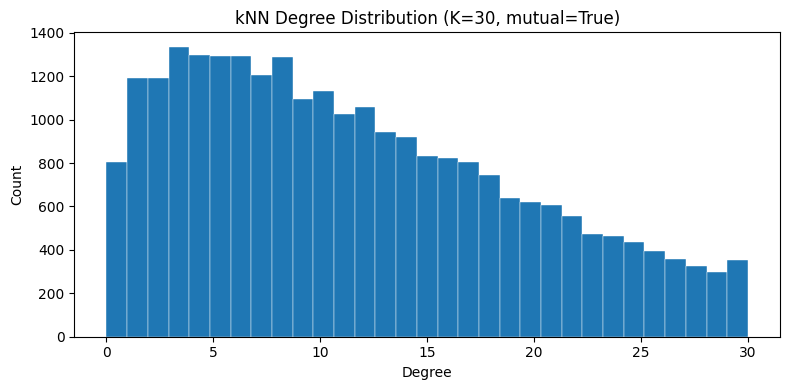

In [5]:
# §2  kNN Edge Construction
# ══════════════════════════════════════════════════════════════════════

def build_knn_edges(emb, k=30, method="faiss_exact", tau=None,
                    mutual=True, self_loop=False):
    """Build Top-K similarity edge list. Returns DataFrame[i, j, sim]."""
    n = emb.shape[0]
    search_k = k + 1

    t0 = time.time()
    if method == "faiss_exact":
        import faiss
        index = faiss.IndexFlatIP(emb.shape[1])
        index.add(emb)
        sims, ids = index.search(emb, search_k)
    elif method == "faiss_ivf":
        import faiss
        nlist = max(16, int(np.sqrt(n)))
        quantizer = faiss.IndexFlatIP(emb.shape[1])
        index = faiss.IndexIVFFlat(quantizer, emb.shape[1], nlist,
                                   faiss.METRIC_INNER_PRODUCT)
        index.train(emb)
        index.add(emb)
        index.nprobe = min(nlist, 32)
        sims, ids = index.search(emb, search_k)
    elif method == "hnswlib":
        import hnswlib
        idx = hnswlib.Index(space='ip', dim=emb.shape[1])
        idx.init_index(max_elements=n, ef_construction=200, M=32)
        idx.add_items(emb, np.arange(n))
        idx.set_ef(max(search_k * 2, 100))
        ids, sims = idx.knn_query(emb, k=search_k)
    else:
        raise ValueError(f"Unknown method: {method}")

    print(f"kNN search done in {time.time()-t0:.1f}s  (method={method}, k={k})")

    # Build edge list
    src = np.repeat(np.arange(n, dtype=np.int32), search_k)
    dst = ids.ravel().astype(np.int32)
    sim = sims.ravel().astype(np.float32)

    if not self_loop:
        mask = src != dst
        src, dst, sim = src[mask], dst[mask], sim[mask]
    valid = dst >= 0
    src, dst, sim = src[valid], dst[valid], sim[valid]

    if tau is not None:
        keep = sim >= tau
        src, dst, sim = src[keep], dst[keep], sim[keep]
        print(f"After tau={tau}: {len(src):,} directed edges")

    if mutual:
        edge_set = set(zip(src.tolist(), dst.tolist()))
        mutual_mask = np.array(
            [(d, s) in edge_set for s, d in zip(src.tolist(), dst.tolist())],
            dtype=bool)
        src, dst, sim = src[mutual_mask], dst[mutual_mask], sim[mutual_mask]
        swap = src > dst
        src[swap], dst[swap] = dst[swap].copy(), src[swap].copy()
        edges_df = pd.DataFrame({"i": src, "j": dst, "sim": sim})
        edges_df = edges_df.drop_duplicates(subset=["i", "j"]).reset_index(drop=True)
        print(f"Mutual kNN undirected edges: {len(edges_df):,}")
    else:
        swap = src > dst
        src[swap], dst[swap] = dst[swap].copy(), src[swap].copy()
        edges_df = pd.DataFrame({"i": src, "j": dst, "sim": sim})
        edges_df = edges_df.groupby(["i", "j"], as_index=False)["sim"].max()
        print(f"Undirected edges: {len(edges_df):,}")

    return edges_df


def quick_diagnostics(edges_df, n_nodes, k, figs_dir):
    """Sim distribution, connectivity, degree histogram."""
    print(f"\n-- Quick Diagnostics --")
    print(f"Edges: {len(edges_df):,}")
    print("Sim distribution:")
    for q in [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]:
        print(f"  p{int(q*100):02d} = {edges_df['sim'].quantile(q):.4f}")

    deg = pd.concat([edges_df["i"], edges_df["j"]]).value_counts()
    all_nodes = pd.Series(0, index=range(n_nodes))
    all_nodes.update(deg)
    deg_full = all_nodes.values
    print(f"Mean degree: {deg_full.mean():.1f}")
    print(f"Isolated nodes (deg=0): {(deg_full == 0).sum():,}")

    # Connected components (union-find)
    parent = list(range(n_nodes))
    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x
    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb: parent[ra] = rb
    for _, row in tqdm(edges_df.iterrows(), total=len(edges_df),
                       desc="Union-Find", disable=len(edges_df)<100_000):
        union(int(row["i"]), int(row["j"]))
    comps = pd.Series([find(x) for x in range(n_nodes)]).nunique()
    print(f"Connected components: {comps:,}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(deg_full, bins=min(80, int(deg_full.max())+1),
            edgecolor="white", linewidth=0.3)
    ax.set_xlabel("Degree"); ax.set_ylabel("Count")
    ax.set_title(f"kNN Degree Distribution (K={k}, mutual={MUTUAL})")
    plt.tight_layout()
    fig.savefig(figs_dir / "knn_degree_hist.png", dpi=150)
    plt.show()

    return {"mean_degree": round(float(deg_full.mean()), 2),
            "isolated_nodes": int((deg_full == 0).sum()),
            "connected_components": int(comps)}


edges_raw = build_knn_edges(emb, k=K, method=METHOD, tau=TAU, mutual=MUTUAL)
diag = quick_diagnostics(edges_raw, N, K, FIGS_DIR)


## §3  Attach Node Attributes to Edges & Export

Annotate each edge with year, country, topic from both endpoints; export `edges.parquet`.

In [6]:
# §3  Annotate Edges & Export
# ══════════════════════════════════════════════════════════════════════

def annotate_edges(edges_df, df):
    """Attach year, country, topic from both endpoints."""
    attrs = df[["year", "country2", "topic"]].copy()
    attrs.columns = ["year", "country", "topic"]
    e = edges_df.copy()
    for side, sfx in [("i", "_i"), ("j", "_j")]:
        for c in ["year", "country", "topic"]:
            e[c + sfx] = attrs[c].values[e[side].values]
    return e

edges = annotate_edges(edges_raw, df)
edges.to_parquet(OUTPUT_DIR / "edges.parquet", index=False)
print(f"Saved edges.parquet ({len(edges):,} edges)")
edges.head()


Saved edges.parquet (149,705 edges)


,i,j,sim,year_i,country_i,topic_i,year_j,country_j,topic_j
0,2,25458,0.908321,1990,OTHER,-1,2014,OTHER,23
1,2,24670,0.889052,1990,OTHER,-1,2013,OTHER,23
2,2,24051,0.884495,1990,OTHER,-1,2013,OTHER,-1
3,2,3077,0.880770,1990,OTHER,-1,2016,OTHER,-1
4,4,2265,0.938784,1990,OTHER,-1,1996,OTHER,-1


## §4  Community Detection (Leiden) & Node-Level Metrics

Build an `igraph` graph, run Leiden partitioning, compute degree / strength / coreness / betweenness.

igraph built in 0.0s (V=25,794, E=149,705)
Leiden: 912 communities, modularity=0.8262
Betweenness method: sampled_5000
Saved nodes.parquet (25,794 nodes)
Saved communities.parquet


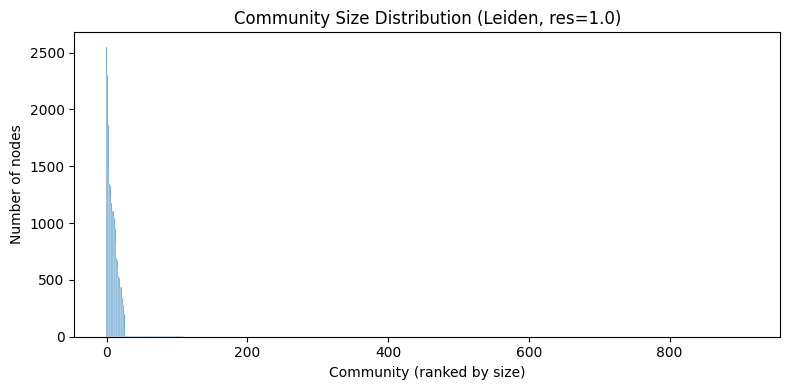

Communities: 912  Modularity: 0.8262  Largest frac: 0.0989


In [7]:
# §4  Community Detection & Node Metrics
# ══════════════════════════════════════════════════════════════════════
import igraph as ig
import leidenalg as la


def build_igraph(edges_df, n_nodes):
    """Build weighted undirected igraph from edge DataFrame."""
    g = ig.Graph(n=n_nodes, directed=False)
    g.add_edges(list(zip(edges_df["i"].tolist(), edges_df["j"].tolist())))
    g.es["weight"] = edges_df["sim"].tolist()
    return g


def run_leiden(g, resolution=1.0, seed=42):
    """Leiden community detection; returns membership list."""
    part = la.find_partition(
        g, la.RBConfigurationVertexPartition,
        weights="weight", resolution_parameter=resolution, seed=seed)
    membership = part.membership
    modularity = g.modularity(membership, weights="weight")
    n_comm = len(set(membership))
    print(f"Leiden: {n_comm} communities, modularity={modularity:.4f}")
    return membership, modularity


def compute_node_metrics(g, n_nodes, betweenness_k=5000, seed=42):
    """Compute degree, strength, coreness, betweenness (sampled)."""
    degree   = g.degree()
    strength = g.strength(weights="weight")
    coreness = g.coreness()

    if n_nodes <= betweenness_k:
        betw = g.betweenness(weights="weight")
        betw_method = "exact"
    else:
        rng = np.random.RandomState(seed)
        sample_ids = rng.choice(n_nodes, size=min(betweenness_k, n_nodes),
                                replace=False).tolist()
        betw_partial = g.betweenness(vertices=sample_ids, weights="weight")
        betw = [np.nan] * n_nodes
        for idx, bid in zip(sample_ids, betw_partial):
            betw[idx] = bid
        betw_method = f"sampled_{len(sample_ids)}"

    print(f"Betweenness method: {betw_method}")
    return degree, strength, coreness, betw, betw_method


t0 = time.time()
G = build_igraph(edges_raw, N)
print(f"igraph built in {time.time()-t0:.1f}s (V={G.vcount():,}, E={G.ecount():,})")

membership, modularity = run_leiden(G, resolution=LEIDEN_RES, seed=SEED)
degree, strength, coreness, betw, betw_method = compute_node_metrics(
    G, N, betweenness_k=BETWEENNESS_K, seed=SEED)

# Build nodes DataFrame
nodes = pd.DataFrame({
    "paper_id":    df["paper_id"].values,
    "year":        df["year"].values,
    "country":     df["country2"].values,
    "topic":       df["topic"].values,
    "citation":    df["citation"].values,
    "community_id": membership,
    "degree":      degree,
    "strength":    np.round(strength, 4),
    "coreness":    coreness,
    "betweenness_approx": betw,
})
nodes.to_parquet(OUTPUT_DIR / "nodes.parquet", index=False)
print(f"Saved nodes.parquet ({len(nodes):,} nodes)")

comm_df = nodes[["paper_id", "community_id"]].copy()
comm_df.to_parquet(OUTPUT_DIR / "communities.parquet", index=False)
print("Saved communities.parquet")

# Community size histogram
comm_sizes = pd.Series(membership).value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(len(comm_sizes)), comm_sizes.values, width=1.0,
       edgecolor="white", linewidth=0.3)
ax.set_xlabel("Community (ranked by size)")
ax.set_ylabel("Number of nodes")
ax.set_title(f"Community Size Distribution (Leiden, res={LEIDEN_RES})")
plt.tight_layout()
fig.savefig(FIGS_DIR / "community_size_hist.png", dpi=150)
plt.show()

comm_stats = {
    "n_communities": int(len(comm_sizes)),
    "modularity": round(float(modularity), 4),
    "largest_community_frac": round(float(comm_sizes.iloc[0] / N), 4),
    "betweenness_method": betw_method,
}
print(f"Communities: {comm_stats['n_communities']}  "
      f"Modularity: {comm_stats['modularity']}  "
      f"Largest frac: {comm_stats['largest_community_frac']}")


## §5  Cross-Country Connectivity & Structural Insight

- Cross-country edge ratios (overall & by year)
- Attribute assortativity (country, topic)
- Country mixing heatmap
- Bridging edges & bridging nodes

Cross-country edges: 49,067/149,705 = 0.3278
CN-US edges: 5,417/149,705 = 0.0362
Edge pair counts: {'OTHER-OTHER': 70228, 'CN-OTHER': 26856, 'CN-CN': 24791, 'OTHER-US': 16794, 'US-US': 5619, 'CN-US': 5417}


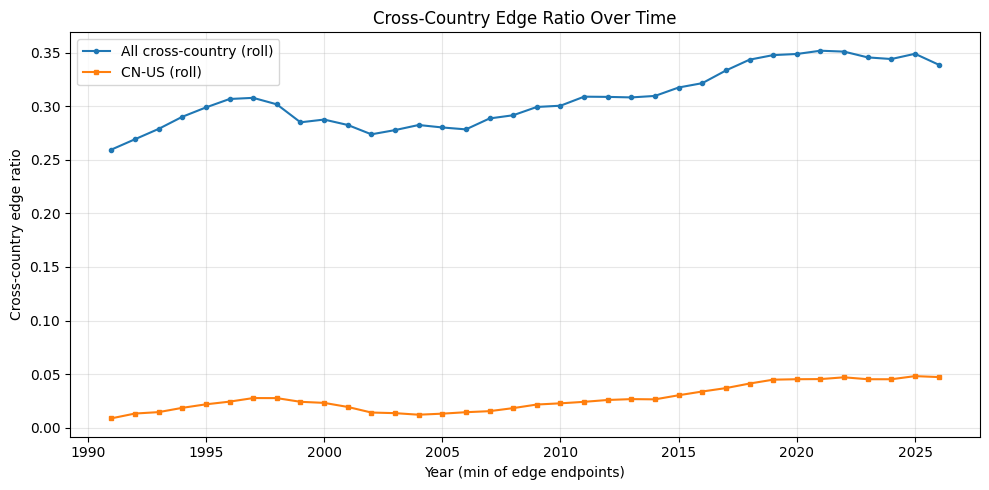

Assortativity country=0.3821  topic=0.7037  [sampled_50000]


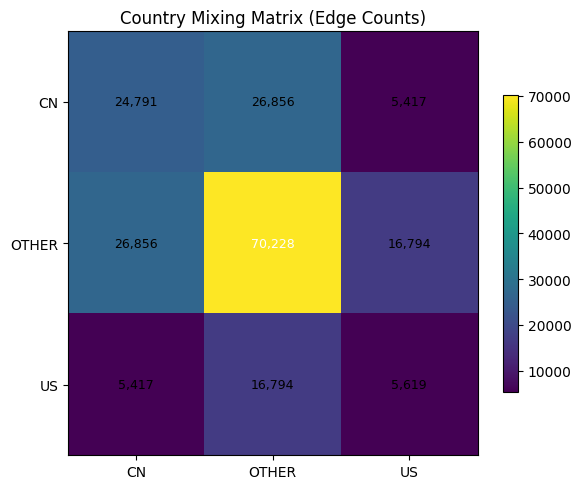

Bridge edges: 17,786 (0.1188)

Top 10 bridging nodes:
           paper_id  year country  topic  community_id  degree  coreness  betweenness_approx  bridging_ratio
WOS:000994303400001  2023      US     24             7       8         6           1364050.0        0.600000
WOS:001475452000001  2025      CN     -1             0      21         8           1010691.0        0.526316
WOS:000708730500001  2022   OTHER     -1             1      22         9            874942.0        0.384615
WOS:000944261900001  2023      CN     23            21      18         9            840696.0        0.166667
WOS:000308721100020  2012      CN     -1             5      13         8            819901.0        1.000000
WOS:000332034400082  2014   OTHER     -1             8      22         8            797522.5        0.545455
WOS:A1997YF28600018  1997   OTHER     27            17      12         7            771759.0        0.500000
WOS:000410796300004  2017      CN     -1             6      16         8  

In [8]:
# §5  Cross-Country Connectivity & Structure
# ══════════════════════════════════════════════════════════════════════
import networkx as nx


def cross_country_analysis(edges, nodes, figs_dir, rolling_w=5):
    """
    A) Cross-country edge ratios.
    B) Assortativity.
    C) Country mixing heatmap.
    D) Bridging edges & nodes.
    """
    results = {}

    # ── A) Cross-country edge ratio ───────────────────────────────────
    e = edges.copy()
    e["cross_any"]  = e["country_i"] != e["country_j"]
    e["cn_us_edge"] = (
        ((e["country_i"] == "CN") & (e["country_j"] == "US")) |
        ((e["country_i"] == "US") & (e["country_j"] == "CN")))
    total = len(e)
    cross_any_n = int(e["cross_any"].sum())
    cn_us_n     = int(e["cn_us_edge"].sum())
    results["cross_country_ratio"] = round(cross_any_n / total, 4) if total else 0
    results["cn_us_edge_ratio"]    = round(cn_us_n / total, 4) if total else 0
    print(f"Cross-country edges: {cross_any_n:,}/{total:,} = "
          f"{results['cross_country_ratio']:.4f}")
    print(f"CN-US edges: {cn_us_n:,}/{total:,} = {results['cn_us_edge_ratio']:.4f}")

    # Edge pair counts — use pandas min/max (np.minimum/maximum don't support str)
    ci_str = e["country_i"].astype(str)
    cj_str = e["country_j"].astype(str)
    tmp = pd.concat([ci_str.rename("a"), cj_str.rename("b")], axis=1)
    ca = tmp.min(axis=1)
    cb = tmp.max(axis=1)
    pair_counts = (ca + "-" + cb).value_counts().to_dict()
    results["edge_pair_counts"] = {k: int(v) for k, v in pair_counts.items()}
    print(f"Edge pair counts: {results['edge_pair_counts']}")

    # ── Time series ───────────────────────────────────────────────────
    has_year = e["year_i"].notna().any() and e["year_j"].notna().any()
    ts_records = []
    if has_year:
        yi = pd.to_numeric(e["year_i"], errors="coerce")
        yj = pd.to_numeric(e["year_j"], errors="coerce")
        e["edge_year"] = (pd.concat([yi.rename("yi"), yj.rename("yj")], axis=1)
                          .min(axis=1).astype("Int64"))
        e = e[e["edge_year"] > 1900].copy()
        yearly = e.groupby("edge_year").agg(
            total=("sim", "count"),
            cross=("cross_any", "sum"),
            cn_us=("cn_us_edge", "sum")).reset_index()
        yearly["cross_ratio"] = yearly["cross"] / yearly["total"]
        yearly["cn_us_ratio"] = yearly["cn_us"] / yearly["total"]
        yearly = yearly.sort_values("edge_year")
        yearly["cross_ratio_roll"] = yearly["cross_ratio"].rolling(
            rolling_w, min_periods=2).mean()
        yearly["cn_us_ratio_roll"] = yearly["cn_us_ratio"].rolling(
            rolling_w, min_periods=2).mean()
        ts_records = yearly.to_dict("records")

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(yearly["edge_year"], yearly["cross_ratio_roll"],
                "o-", markersize=3, label="All cross-country (roll)")
        ax.plot(yearly["edge_year"], yearly["cn_us_ratio_roll"],
                "s-", markersize=3, label="CN-US (roll)")
        ax.set_xlabel("Year (min of edge endpoints)")
        ax.set_ylabel("Cross-country edge ratio")
        ax.set_title("Cross-Country Edge Ratio Over Time")
        ax.legend(); ax.grid(True, alpha=0.3)
        plt.tight_layout()
        fig.savefig(figs_dir / "cross_country_over_time.png", dpi=150)
        plt.show()
    results["cross_country_time_series"] = ts_records

    # ── B) Assortativity ──────────────────────────────────────────────
    max_nx = 50_000
    e_nx = edges if len(edges) <= max_nx else edges.sample(n=max_nx, random_state=SEED)
    assort_note = "full" if len(edges) <= max_nx else f"sampled_{max_nx}"
    Gnx = nx.Graph()
    for _, r in e_nx.iterrows():
        Gnx.add_edge(int(r["i"]), int(r["j"]), weight=float(r["sim"]))
    top_topics = nodes["topic"].value_counts().head(15).index.tolist()
    for nid in Gnx.nodes():
        if nid < len(nodes):
            Gnx.nodes[nid]["country"] = nodes.iloc[nid]["country"]
            t = int(nodes.iloc[nid]["topic"])
            Gnx.nodes[nid]["topic_grp"] = t if t in top_topics else -99
    try:
        ac = nx.attribute_assortativity_coefficient(Gnx, "country")
    except Exception:
        ac = np.nan
    try:
        at = nx.attribute_assortativity_coefficient(Gnx, "topic_grp")
    except Exception:
        at = np.nan
    results["assortativity_country"] = round(float(ac), 4) if not np.isnan(ac) else None
    results["assortativity_topic"]   = round(float(at), 4) if not np.isnan(at) else None
    results["assortativity_note"]    = assort_note
    print(f"Assortativity country={results['assortativity_country']}  "
          f"topic={results['assortativity_topic']}  [{assort_note}]")

    # ── C) Country mixing heatmap ─────────────────────────────────────
    country_labels = sorted(nodes["country"].unique())
    n_cl = len(country_labels)
    cl2i = {c: i for i, c in enumerate(country_labels)}
    mix = np.zeros((n_cl, n_cl), dtype=int)
    ci_arr = edges["country_i"].map(cl2i).fillna(-1).astype(int).values
    cj_arr = edges["country_j"].map(cl2i).fillna(-1).astype(int).values
    for ci, cj in zip(ci_arr, cj_arr):
        if ci >= 0 and cj >= 0:
            mix[ci, cj] += 1
            if ci != cj:
                mix[cj, ci] += 1

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mix, aspect="auto")
    ax.set_xticks(range(n_cl)); ax.set_xticklabels(country_labels)
    ax.set_yticks(range(n_cl)); ax.set_yticklabels(country_labels)
    for i2 in range(n_cl):
        for j2 in range(n_cl):
            ax.text(j2, i2, f"{mix[i2,j2]:,}", ha="center", va="center",
                    fontsize=9,
                    color="white" if mix[i2,j2] > mix.max()*0.5 else "black")
    ax.set_title("Country Mixing Matrix (Edge Counts)")
    plt.colorbar(im, ax=ax, shrink=0.7)
    plt.tight_layout()
    fig.savefig(figs_dir / "community_country_heatmap.png", dpi=150)
    plt.show()

    # ── D) Bridging edges & nodes ─────────────────────────────────────
    comm_map = nodes["community_id"].values
    ea = edges.copy()
    ea["comm_i"] = comm_map[ea["i"].values]
    ea["comm_j"] = comm_map[ea["j"].values]
    ea["bridge"] = ea["comm_i"] != ea["comm_j"]
    results["n_bridge_edges"] = int(ea["bridge"].sum())
    results["bridge_edge_ratio"] = round(
        results["n_bridge_edges"] / len(ea), 4) if len(ea) else 0
    print(f"Bridge edges: {results['n_bridge_edges']:,} "
          f"({results['bridge_edge_ratio']:.4f})")

    # Bridging ratio per node
    bri = ea.groupby("i")["bridge"].mean()
    brj = ea.groupby("j")["bridge"].mean()
    br = pd.DataFrame({"br": bri}).reindex(range(len(nodes)), fill_value=0)
    br_j = pd.DataFrame({"br": brj}).reindex(range(len(nodes)), fill_value=0)
    br["br"] = np.maximum(br["br"].values, br_j["br"].values)
    nodes["bridging_ratio"] = br["br"].values

    top_bridge = nodes.nlargest(50, "betweenness_approx")[
        ["paper_id","year","country","topic","community_id",
         "degree","coreness","betweenness_approx","bridging_ratio"]]
    print(f"\nTop 10 bridging nodes:")
    print(top_bridge.head(10).to_string(index=False))
    return results, ea[ea["bridge"]].head(100), top_bridge


cross_results, bridge_edges_df, bridge_nodes_df = cross_country_analysis(
    edges, nodes, FIGS_DIR, rolling_w=ROLLING_WINDOW)


## §6  Time Evolution — Core Share

CN / US share in k-core top layer over time.

High-core threshold (>= 9.0): 8,124 nodes


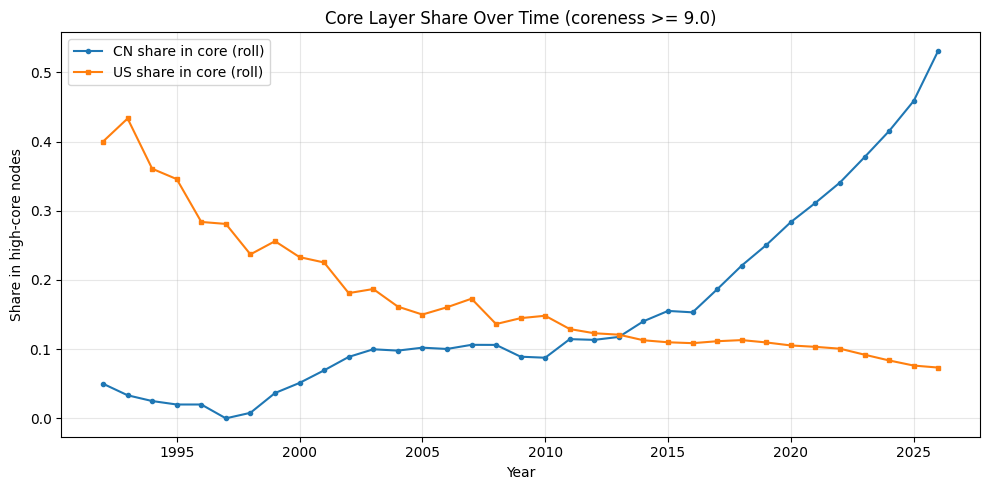

In [9]:
# §6  Time Evolution — Core Share
# ══════════════════════════════════════════════════════════════════════

def core_share_over_time(nodes_df, figs_dir, rolling_w=5):
    """CN / US share among high-coreness nodes, by year."""
    if nodes_df["year"].isna().all():
        print("No year data; skipping")
        return []

    q75 = nodes_df["coreness"].quantile(0.75)
    if q75 == 0:
        q75 = nodes_df["coreness"].quantile(0.90)
    high_core = nodes_df[nodes_df["coreness"] >= q75].copy()
    print(f"High-core threshold (>= {q75}): {len(high_core):,} nodes")

    yearly = high_core.groupby("year")["country"].value_counts().unstack(fill_value=0)
    for c in ["CN", "US", "OTHER"]:
        if c not in yearly.columns:
            yearly[c] = 0
    yearly["total"] = yearly.sum(axis=1)
    yearly["CN_share"] = yearly["CN"] / yearly["total"]
    yearly["US_share"] = yearly["US"] / yearly["total"]
    yearly = yearly.reset_index().sort_values("year")
    yearly = yearly[yearly["year"] > 1900]
    yearly["CN_share_roll"] = yearly["CN_share"].rolling(rolling_w, min_periods=2).mean()
    yearly["US_share_roll"] = yearly["US_share"].rolling(rolling_w, min_periods=2).mean()

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(yearly["year"], yearly["CN_share_roll"], "o-",
            markersize=3, label="CN share in core (roll)")
    ax.plot(yearly["year"], yearly["US_share_roll"], "s-",
            markersize=3, label="US share in core (roll)")
    ax.set_xlabel("Year"); ax.set_ylabel("Share in high-core nodes")
    ax.set_title(f"Core Layer Share Over Time (coreness >= {q75})")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(figs_dir / "core_share_over_time.png", dpi=150)
    plt.show()

    return yearly[["year","CN","US","OTHER","total",
                    "CN_share_roll","US_share_roll"]].to_dict("records")

core_ts = core_share_over_time(nodes, FIGS_DIR, rolling_w=ROLLING_WINDOW)


## §7  Interactive Visualisation (Sampled Sub-Graph)

Sample ≤ `SAMPLING_SIZE` nodes (stratified by community), spring layout, Plotly HTML.
Also: community × topic cross-table (+ NMI).

In [10]:
# §7  Interactive Sampled Graph Visualisation
# ══════════════════════════════════════════════════════════════════════
import plotly.graph_objects as go


def sample_subgraph(nodes_df, edges_df, max_nodes=5000, seed=42):
    """Stratified sampling up to max_nodes."""
    rng = np.random.RandomState(seed)
    n_comms = nodes_df["community_id"].nunique()
    max_per = max(10, max_nodes // n_comms)
    sampled_ids = []
    for cid, grp in nodes_df.groupby("community_id"):
        ids = grp.index.tolist()
        if len(ids) > max_per:
            ids = rng.choice(ids, size=max_per, replace=False).tolist()
        sampled_ids.extend(ids)
    if len(sampled_ids) > max_nodes:
        sampled_ids = rng.choice(sampled_ids, size=max_nodes, replace=False).tolist()

    id_set = set(sampled_ids)
    sub_edges = edges_df[
        edges_df["i"].isin(id_set) & edges_df["j"].isin(id_set)].copy()
    old2new = {old: new for new, old in enumerate(sorted(id_set))}
    sub_nodes = nodes_df.loc[sorted(id_set)].reset_index(drop=True)
    sub_edges["i"] = sub_edges["i"].map(old2new)
    sub_edges["j"] = sub_edges["j"].map(old2new)
    sub_edges = sub_edges.dropna(subset=["i", "j"])
    sub_edges["i"] = sub_edges["i"].astype(int)
    sub_edges["j"] = sub_edges["j"].astype(int)
    print(f"Sampled sub-graph: {len(sub_nodes):,} nodes, {len(sub_edges):,} edges")
    return sub_nodes, sub_edges, old2new


def make_interactive_graph(sub_nodes, sub_edges, output_path, seed=42):
    """Spring layout + Plotly scatter."""
    n = len(sub_nodes)
    g = ig.Graph(n=n, directed=False)
    el = list(zip(sub_edges["i"].tolist(), sub_edges["j"].tolist()))
    if el:
        g.add_edges(el)

    print("Computing layout ...")
    np.random.seed(seed)
    layout = g.layout_fruchterman_reingold(niter=500)
    coords = np.array(layout.coords)
    
    max_draw = 20_000
    draw_e = sub_edges if len(sub_edges) <= max_draw else \
             sub_edges.sample(n=max_draw, random_state=seed)
    edge_x, edge_y = [], []
    for _, r in draw_e.iterrows():
        ii, jj = int(r["i"]), int(r["j"])
        if ii < len(coords) and jj < len(coords):
            edge_x += [coords[ii,0], coords[jj,0], None]
            edge_y += [coords[ii,1], coords[jj,1], None]

    edge_trace = go.Scatter(
        x=edge_x, y=edge_y, mode="lines",
        line=dict(width=0.3, color="rgba(180,180,180,0.3)"),
        hoverinfo="none")
    hover = [
        f"id={r['paper_id']}<br>year={r['year']}<br>"
        f"country={r['country']}<br>topic={r['topic']}<br>"
        f"comm={r['community_id']}<br>deg={r['degree']}"
        for _, r in sub_nodes.iterrows()]
    node_trace = go.Scatter(
        x=coords[:, 0], y=coords[:, 1], mode="markers",
        marker=dict(size=4, color=sub_nodes["community_id"].values,
                    colorscale="Turbo", showscale=True,
                    colorbar=dict(title="Community"),
                    line=dict(width=0.2, color="white")),
        text=hover, hoverinfo="text")

    fig = go.Figure(data=[edge_trace, node_trace])
    fig.update_layout(
        title=f"Sampled Paper KNN Graph ({len(sub_nodes):,} nodes)",
        showlegend=False,
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        width=1200, height=900, template="plotly_white")
    fig.write_html(str(output_path))
    print(f"Saved {output_path}")
    try:
        fig.show()
    except Exception as _e:
        print(f"fig.show() failed ({_e}); open the HTML file instead.")


def community_topic_crosstab(nodes_df):
    """Community x Topic cross-table + NMI."""
    valid = nodes_df[nodes_df["topic"] != -1].copy()
    if len(valid) == 0:
        print("No valid topics for cross-tab")
        return None, None
    ct = pd.crosstab(valid["community_id"], valid["topic"])
    print(f"Community x Topic cross-tab: {ct.shape}")
    try:
        from sklearn.metrics import normalized_mutual_info_score
        nmi = normalized_mutual_info_score(
            valid["community_id"].values, valid["topic"].values)
        print(f"NMI(community, topic) = {nmi:.4f}")
    except Exception:
        nmi = None
    return ct, nmi


sub_nodes, sub_edges, _ = sample_subgraph(
    nodes, edges_raw, max_nodes=SAMPLING_SIZE, seed=SEED)
make_interactive_graph(
    sub_nodes, sub_edges, FIGS_DIR / "sampled_graph.html", seed=SEED)
ct_table, nmi_val = community_topic_crosstab(nodes)


Sampled sub-graph: 1,256 nodes, 146 edges
Computing layout ...
Saved output/graph/figs/sampled_graph.html


Community x Topic cross-tab: (396, 64)
NMI(community, topic) = 0.7693


## §8  Summary Export & Product Manifest

In [11]:
# §8  Summary JSON & Manifest
# ══════════════════════════════════════════════════════════════════════

def build_summary(N, K, TAU, MUTUAL, METHOD, LEIDEN_RES,
                  diag, comm_stats, cross_results, core_ts, nmi_val):
    """Compile all key metrics into summary dict."""
    s = {
        "config": {"N": int(N), "K": int(K), "tau": TAU,
                   "mutual": MUTUAL, "method": METHOD,
                   "leiden_resolution": LEIDEN_RES},
        "graph_diagnostics": diag,
        "community": comm_stats,
        "cross_country": {
            k: v for k, v in cross_results.items()
            if k != "cross_country_time_series"},
    }
    if core_ts:
        s["core_share_time_series_sample"] = core_ts[:5]
    if nmi_val is not None:
        s["nmi_community_topic"] = round(float(nmi_val), 4)
    return s


summary = build_summary(N, K, TAU, MUTUAL, METHOD, LEIDEN_RES,
                        diag, comm_stats, cross_results, core_ts, nmi_val)


def _json_default(obj):
    if isinstance(obj, (np.integer,)):   return int(obj)
    if isinstance(obj, (np.floating,)):  return float(obj)
    if isinstance(obj, np.ndarray):      return obj.tolist()
    if isinstance(obj, pd.Timestamp):    return str(obj)
    try:
        if pd.isna(obj): return None
    except (TypeError, ValueError):
        pass
    return str(obj)


with open(OUTPUT_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=_json_default)
print("Saved summary.json")

# Product manifest
print(f"\n{'='*60}")
print(f"  Paper KNN Graph  --  Product Manifest")
print(f"  {OUTPUT_DIR.resolve()}")
print(f"{'='*60}")
for root, dirs, files in os.walk(OUTPUT_DIR):
    level = root.replace(str(OUTPUT_DIR), "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{Path(root).name}/")
    for fn in sorted(files):
        fp = Path(root) / fn
        sz = fp.stat().st_size
        unit, val = ("MB", sz/1_048_576) if sz >= 1_048_576 else ("KB", sz/1024)
        print(f"{indent}  {fn}  ({val:.1f} {unit})")
print(f"\nPaper KNN Graph pipeline complete!")


Saved summary.json

  Paper KNN Graph  --  Product Manifest
  /Users/luoyiti/Project/catch-up/output/graph
graph/
  communities.parquet  (285.0 KB)
  edges.parquet  (1.7 MB)
  nodes.parquet  (577.1 KB)
  summary.json  (1.7 KB)
  figs/
    community_country_heatmap.png  (40.2 KB)
    community_size_hist.png  (31.7 KB)
    core_share_over_time.png  (72.9 KB)
    cross_country_over_time.png  (63.1 KB)
    knn_degree_hist.png  (27.4 KB)
    sampled_graph.html  (4.8 MB)

Paper KNN Graph pipeline complete!


# §9 Citation vs Similarity Network — Visual Comparisons (8 Figures)

This section compares the citation network (directed, citation edges) and the embedding similarity network (undirected, weighted edges) on aligned paper nodes.
For visual comparability, edge-set overlap and PR evaluation are computed on **undirected normalized edges**.
All figures/tables in this section are written to `output/compare_networks/`.

In [12]:
# §9 Config & Inputs
from pathlib import Path
import os
import re
import json
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import networkx as nx

warnings.filterwarnings("ignore")

# --- Paths ---
CITATION_EDGES_PATH = "output/citation_results/edges.parquet"
SIM_EDGES_PATH = "output/knn_results/edges.parquet"  # auto-detect fallback if missing
NODES_PATH = None  # prefer in-memory df/nodes first

BASE_COMPARE_DIR = Path("output/compare_networks")
FIGS_DIR = BASE_COMPARE_DIR / "figs"
TABLES_DIR = BASE_COMPARE_DIR / "tables"
CACHE_DIR = BASE_COMPARE_DIR / "cache"

for _d in [FIGS_DIR, TABLES_DIR, CACHE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# --- Scale / visual control ---
VIS_MAX_NODES = 800
ADJ_N = 400
COMM_MAX_NODES = 5000
MAX_EDGE_DRAW_MULTIPLIER = 2.0

# Similarity edge density control
SIM_EDGE_MODE = "topM_match_cite"  # topM_match_cite | topK_per_node
SIM_TOPK_PER_NODE = 20

# Alignment / reproducibility
HARMONIZE_MODE = "intersection"  # intersection | union
LAYOUT_SEED = 42
PR_KS_BASE = [100, 200, 500, 1000, 2000, 5000, 10000]

# Optional overlay style
OVERLAY_LAYER_OFFSET = 0.08

print("§9 config ready")
print(f"  FIGS_DIR   = {FIGS_DIR}")
print(f"  TABLES_DIR = {TABLES_DIR}")
print(f"  CACHE_DIR  = {CACHE_DIR}")

§9 config ready
  FIGS_DIR   = output/compare_networks/figs
  TABLES_DIR = output/compare_networks/tables
  CACHE_DIR  = output/compare_networks/cache


In [13]:
# §9 Helper Functions

def _read_table_auto(path):
    """Read parquet/csv if exists; return DataFrame or None."""
    if path is None:
        return None
    p = Path(path)
    candidates = [p]
    if p.suffix.lower() in {".parquet", ".csv"}:
        alt = p.with_suffix(".csv" if p.suffix.lower() == ".parquet" else ".parquet")
        candidates.append(alt)

    for c in candidates:
        if not c.exists():
            continue
        try:
            if c.suffix.lower() == ".parquet":
                return pd.read_parquet(c)
            if c.suffix.lower() == ".csv":
                return pd.read_csv(c)
        except Exception as e:
            print(f"[warn] failed reading {c}: {e}")
    return None


def _first_existing(paths):
    for p in paths:
        if p and Path(p).exists():
            return str(p)
    return None


def _normalize_country(v):
    s = str(v) if pd.notna(v) else ""
    s_low = s.lower()
    if s in {"CN", "CHN"} or "china" in s_low:
        return "CN"
    if s in {"US", "USA"} or "united states" in s_low:
        return "US"
    if s.upper() == "OTHER":
        return "OTHER"
    return "OTHER"


def _ensure_nodes_df(nodes_like):
    """Return normalized node table with required columns."""
    if nodes_like is None or len(nodes_like) == 0:
        return pd.DataFrame(columns=["paper_id", "country", "year", "topic", "country_norm"])

    ndf = nodes_like.copy()

    if "paper_id" not in ndf.columns:
        if ndf.index.name == "paper_id":
            ndf = ndf.reset_index()
        else:
            ndf = ndf.reset_index(drop=True)
            ndf["paper_id"] = [f"paper_{i}" for i in range(len(ndf))]

    # country column
    if "country" in ndf.columns:
        pass
    elif "country2" in ndf.columns:
        ndf["country"] = ndf["country2"]
    elif "country_group" in ndf.columns:
        ndf["country"] = ndf["country_group"]
    else:
        ndf["country"] = "OTHER"

    # year column
    if "year" not in ndf.columns:
        ndf["year"] = pd.NA
    ndf["year"] = pd.to_numeric(ndf["year"], errors="coerce").astype("Int64")

    # topic column
    if "topic" not in ndf.columns:
        topic_col = None
        for c in ["topic_reduced", "topic_reassign", "topic_id"]:
            if c in ndf.columns:
                topic_col = c
                break
        if topic_col is not None:
            ndf["topic"] = pd.to_numeric(ndf[topic_col], errors="coerce").fillna(-1).astype(int)
        else:
            ndf["topic"] = -1
    else:
        ndf["topic"] = pd.to_numeric(ndf["topic"], errors="coerce").fillna(-1).astype(int)

    ndf["paper_id"] = ndf["paper_id"].astype(str)
    ndf["country"] = ndf["country"].fillna("OTHER").astype(str)
    ndf["country_norm"] = ndf["country"].map(_normalize_country)
    return ndf[["paper_id", "country", "country_norm", "year", "topic"]].drop_duplicates("paper_id")


def _infer_edge_cols(df, src_candidates, dst_candidates, w_candidates=None):
    src_col = next((c for c in src_candidates if c in df.columns), None)
    dst_col = next((c for c in dst_candidates if c in df.columns), None)
    w_col = None
    if w_candidates is not None:
        w_col = next((c for c in w_candidates if c in df.columns), None)
    return src_col, dst_col, w_col


def _standardize_citation_edges(edges_df):
    """Return citation edges: src, dst, weight(optional default=1)."""
    if edges_df is None or len(edges_df) == 0:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    src_col, dst_col, w_col = _infer_edge_cols(
        edges_df,
        ["src", "source", "u", "src_paper_id", "citing", "from"],
        ["dst", "target", "v", "dst_paper_id", "cited", "to"],
        ["weight", "count", "w"],
    )

    if src_col is None or dst_col is None:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    out = edges_df[[src_col, dst_col]].copy()
    out.columns = ["src", "dst"]
    out["src"] = out["src"].astype(str)
    out["dst"] = out["dst"].astype(str)
    out = out[(out["src"].str.len() > 0) & (out["dst"].str.len() > 0)]

    if w_col is not None:
        out["weight"] = pd.to_numeric(edges_df[w_col], errors="coerce").fillna(1.0)
    else:
        out["weight"] = 1.0

    out = out[out["src"] != out["dst"]]
    return out.drop_duplicates(["src", "dst"]).reset_index(drop=True)


def _standardize_similarity_edges(edges_df, id_map=None):
    """Return similarity edges: src, dst, weight (paper_id endpoints)."""
    if edges_df is None or len(edges_df) == 0:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    # direct paper-id edges
    src_col, dst_col, w_col = _infer_edge_cols(
        edges_df,
        ["src", "source", "u", "src_paper_id", "paper_id_i"],
        ["dst", "target", "v", "dst_paper_id", "paper_id_j"],
        ["weight", "similarity", "sim", "score"],
    )

    if src_col is not None and dst_col is not None:
        out = edges_df[[src_col, dst_col]].copy()
        out.columns = ["src", "dst"]
        out["src"] = out["src"].astype(str)
        out["dst"] = out["dst"].astype(str)
        if w_col is not None:
            out["weight"] = pd.to_numeric(edges_df[w_col], errors="coerce").fillna(0.0)
        else:
            out["weight"] = 1.0
        out = out[out["src"] != out["dst"]]
        return out.drop_duplicates(["src", "dst"]).reset_index(drop=True)

    # index-based i/j edges -> paper_id map
    if {"i", "j"}.issubset(set(edges_df.columns)) and id_map is not None and len(id_map) > 0:
        out = edges_df[["i", "j"]].copy()
        out["src"] = out["i"].map(id_map)
        out["dst"] = out["j"].map(id_map)
        if "sim" in edges_df.columns:
            out["weight"] = pd.to_numeric(edges_df["sim"], errors="coerce").fillna(0.0)
        elif "weight" in edges_df.columns:
            out["weight"] = pd.to_numeric(edges_df["weight"], errors="coerce").fillna(0.0)
        else:
            out["weight"] = 1.0
        out = out.dropna(subset=["src", "dst"])
        out["src"] = out["src"].astype(str)
        out["dst"] = out["dst"].astype(str)
        out = out[out["src"] != out["dst"]]
        return out[["src", "dst", "weight"]].drop_duplicates(["src", "dst"]).reset_index(drop=True)

    return pd.DataFrame(columns=["src", "dst", "weight"])


def _build_id_map_from_context(nodes_df=None):
    """Build integer-index -> paper_id mapping for i/j similarity edges."""
    if nodes_df is not None and len(nodes_df) > 0:
        try:
            return dict(enumerate(nodes_df["paper_id"].astype(str).tolist()))
        except Exception:
            pass

    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame) and "paper_id" in globals()["df"].columns:
        return dict(enumerate(globals()["df"]["paper_id"].astype(str).tolist()))

    gnodes = _read_table_auto("output/graph/nodes.parquet")
    if gnodes is not None and "paper_id" in gnodes.columns:
        return dict(enumerate(gnodes["paper_id"].astype(str).tolist()))

    return {}


def _fallback_build_sim_edges_from_embeddings(emb_array, k=20):
    """Fallback builder when no similarity edges are found."""
    if emb_array is None:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    try:
        from sklearn.neighbors import NearestNeighbors
        emb = np.asarray(emb_array, dtype=np.float32)
        n = emb.shape[0]
        if n == 0:
            return pd.DataFrame(columns=["src", "dst", "weight"])

        nn = NearestNeighbors(n_neighbors=min(k + 1, n), metric="cosine")
        nn.fit(emb)
        dists, inds = nn.kneighbors(emb)

        src = np.repeat(np.arange(n), inds.shape[1])
        dst = inds.reshape(-1)
        cos_sim = 1.0 - dists.reshape(-1)

        keep = src != dst
        src, dst, cos_sim = src[keep], dst[keep], cos_sim[keep]

        id_map = _build_id_map_from_context()
        out = pd.DataFrame({"i": src, "j": dst, "sim": cos_sim})
        out = _standardize_similarity_edges(out, id_map=id_map)
        return out
    except Exception as e:
        print(f"[warn] embedding fallback failed: {e}")
        return pd.DataFrame(columns=["src", "dst", "weight"])


def _fallback_build_citation_from_cr(df_local):
    """Lightweight DOI-based CR mapping, internal-only."""
    if df_local is None or len(df_local) == 0:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    if "CR" not in df_local.columns or "paper_id" not in df_local.columns:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    if "doi" not in df_local.columns:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    doi_series = df_local["doi"].astype(str).str.strip().str.lower()
    doi_to_pid = {d: p for d, p in zip(doi_series, df_local["paper_id"].astype(str)) if d and d != 'none' and d != 'nan'}

    pat = re.compile(r"10\.\d{4,9}/[-._;()/:A-Z0-9]+", re.I)
    edges = []
    for _, row in df_local[["paper_id", "CR"]].iterrows():
        src = str(row["paper_id"])
        cr = row["CR"] if pd.notna(row["CR"]) else ""
        if not cr:
            continue
        refs = str(cr).split(";")
        for r in refs:
            m = pat.search(r)
            if not m:
                continue
            doi = m.group(0).lower().rstrip('.,;')
            dst = doi_to_pid.get(doi)
            if dst and dst != src:
                edges.append((src, dst, 1.0))

    if not edges:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    out = pd.DataFrame(edges, columns=["src", "dst", "weight"]).drop_duplicates(["src", "dst"]).reset_index(drop=True)
    return out


def _apply_sim_edge_mode(sim_df, mode="topM_match_cite", target_m=0, k_per_node=20):
    """Control similarity edge density for fair visual comparison."""
    if sim_df is None or len(sim_df) == 0:
        return pd.DataFrame(columns=["src", "dst", "weight"])

    x = sim_df.copy()
    x["weight"] = pd.to_numeric(x["weight"], errors="coerce").fillna(0.0)
    x = x.sort_values("weight", ascending=False)

    if mode == "topM_match_cite":
        m = int(target_m) if target_m and target_m > 0 else min(len(x), 10000)
        return x.head(m).reset_index(drop=True)

    if mode == "topK_per_node":
        rev = x.rename(columns={"src": "dst", "dst": "src"})
        bi = pd.concat([x, rev], ignore_index=True)
        bi["rk"] = bi.groupby("src")["weight"].rank(method="first", ascending=False)
        keep = bi[bi["rk"] <= int(k_per_node)].copy()
        keep["u"] = keep[["src", "dst"]].min(axis=1)
        keep["v"] = keep[["src", "dst"]].max(axis=1)
        out = keep.groupby(["u", "v"], as_index=False)["weight"].max().rename(columns={"u": "src", "v": "dst"})
        return out.sort_values("weight", ascending=False).reset_index(drop=True)

    return x.reset_index(drop=True)


def build_citation_graph(edges_df) -> nx.DiGraph:
    g = nx.DiGraph()
    if edges_df is None or len(edges_df) == 0:
        return g
    for _, r in edges_df.iterrows():
        g.add_edge(str(r["src"]), str(r["dst"]), weight=float(r.get("weight", 1.0)))
    return g


def build_similarity_graph(edges_df) -> nx.Graph:
    g = nx.Graph()
    if edges_df is None or len(edges_df) == 0:
        return g

    tmp = edges_df.copy()
    tmp["src"] = tmp["src"].astype(str)
    tmp["dst"] = tmp["dst"].astype(str)
    tmp["weight"] = pd.to_numeric(tmp["weight"], errors="coerce").fillna(0.0)

    # undirected canonical pair + max weight
    tmp["u"] = tmp[["src", "dst"]].min(axis=1)
    tmp["v"] = tmp[["src", "dst"]].max(axis=1)
    agg = tmp.groupby(["u", "v"], as_index=False)["weight"].max()

    for _, r in agg.iterrows():
        g.add_edge(r["u"], r["v"], weight=float(r["weight"]))
    return g


def harmonize_node_set(G_cite, G_sim, nodes_df, mode="intersection"):
    nc = set(G_cite.nodes())
    ns = set(G_sim.nodes())
    nn = set(nodes_df["paper_id"].astype(str)) if (nodes_df is not None and len(nodes_df) > 0) else (nc | ns)

    if mode == "union":
        keep = (nc | ns) & nn
    else:
        keep = (nc & ns & nn) if (len(nc) > 0 and len(ns) > 0) else ((nc | ns) & nn)

    Gc = G_cite.subgraph(keep).copy()
    Gs = G_sim.subgraph(keep).copy()
    nd2 = nodes_df[nodes_df["paper_id"].astype(str).isin(keep)].copy() if nodes_df is not None else pd.DataFrame({"paper_id": list(keep)})
    return Gc, Gs, nd2


def choose_visual_subgraph(Gc, Gs, nodes_df, max_nodes=800, strategy="pagerank_or_degree"):
    keep = set(nodes_df["paper_id"].astype(str))
    if len(keep) <= max_nodes:
        return Gc.subgraph(keep).copy(), Gs.subgraph(keep).copy(), nodes_df.copy()

    score = pd.Series(0.0, index=list(keep), dtype=float)

    if strategy == "pagerank_or_degree" and Gc.number_of_nodes() > 0 and Gc.number_of_edges() > 0:
        try:
            pr = nx.pagerank(Gc.to_undirected())
            score = score.add(pd.Series(pr), fill_value=0)
        except Exception:
            deg = dict(Gc.degree())
            score = score.add(pd.Series(deg, dtype=float), fill_value=0)

    # citation fallback
    if score.sum() == 0 and Gc.number_of_nodes() > 0:
        score = score.add(pd.Series(dict(Gc.in_degree()), dtype=float), fill_value=0)
        score = score.add(pd.Series(dict(Gc.out_degree()), dtype=float), fill_value=0)

    # similarity weighted degree supplement
    if Gs.number_of_nodes() > 0:
        wdeg = dict(Gs.degree(weight="weight"))
        score = score.add(0.5 * pd.Series(wdeg, dtype=float), fill_value=0)

    selected = set(score.sort_values(ascending=False).head(max_nodes).index.tolist())
    ndv = nodes_df[nodes_df["paper_id"].astype(str).isin(selected)].copy()
    return Gc.subgraph(selected).copy(), Gs.subgraph(selected).copy(), ndv


def compute_shared_layout(G_union, seed=42, cache_path=None):
    nodes_now = sorted(G_union.nodes())
    if cache_path is not None:
        cp = Path(cache_path)
        if cp.exists():
            try:
                with open(cp, "rb") as f:
                    cache = pickle.load(f)
                if cache.get("nodes") == nodes_now:
                    return cache.get("pos", {})
            except Exception:
                pass

    if G_union.number_of_nodes() == 0:
        pos = {}
    elif G_union.number_of_edges() == 0:
        rng = np.random.RandomState(seed)
        pos = {n: (float(rng.rand()), float(rng.rand())) for n in G_union.nodes()}
    else:
        pos = nx.spring_layout(G_union, seed=seed, weight="weight", k=None)

    if cache_path is not None:
        cp = Path(cache_path)
        cp.parent.mkdir(parents=True, exist_ok=True)
        with open(cp, "wb") as f:
            pickle.dump({"nodes": nodes_now, "pos": pos}, f)

    return pos


def edge_set(G, directed=False):
    out = set()
    for u, v in G.edges():
        u, v = str(u), str(v)
        if directed:
            out.add((u, v))
        else:
            out.add((u, v) if u <= v else (v, u))
    return out


def safe_draw_network(
    G,
    pos,
    ax,
    node_colors=None,
    edge_alpha=0.2,
    edge_width_mode="uniform",
    title="",
    node_size=10,
    edge_color="#666666",
    max_edges=None,
):
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

    all_nodes = list(G.nodes())
    nodelist = [n for n in all_nodes if n in pos]
    if not nodelist:
        ax.text(0.5, 0.5, "No nodes to draw", ha="center", va="center", transform=ax.transAxes)
        return

    if node_colors is None:
        node_colors = ["#999999"] * len(nodelist)
    elif len(node_colors) == len(all_nodes):
        cmap = dict(zip(all_nodes, node_colors))
        node_colors = [cmap.get(n, "#999999") for n in nodelist]
    elif len(node_colors) != len(nodelist):
        node_colors = ["#999999"] * len(nodelist)

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=nodelist,
        node_color=node_colors,
        node_size=node_size,
        linewidths=0.0,
        ax=ax,
    )

    edges = [(u, v, d) for u, v, d in G.edges(data=True) if u in pos and v in pos]
    if max_edges is not None and len(edges) > max_edges:
        # keep strongest edges when weight exists
        edges = sorted(edges, key=lambda x: float(x[2].get("weight", 1.0)), reverse=True)[:max_edges]

    if len(edges) == 0:
        return

    if edge_width_mode == "weight":
        ws = np.array([float(d.get("weight", 1.0)) for _, _, d in edges], dtype=float)
        if ws.max() > ws.min():
            ws = 0.3 + 1.7 * (ws - ws.min()) / (ws.max() - ws.min())
        else:
            ws = np.full_like(ws, 0.8)
        widths = ws.tolist()
    else:
        widths = [0.6] * len(edges)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=[(u, v) for u, v, _ in edges],
        width=widths,
        edge_color=edge_color,
        alpha=edge_alpha,
        ax=ax,
    )


def community_detect(G_undirected, method="greedy_modularity", max_nodes=5000):
    Gu = G_undirected.copy().to_undirected()
    if Gu.number_of_nodes() == 0:
        return {}

    original_nodes = list(Gu.nodes())
    # downsample for very large graphs
    if Gu.number_of_nodes() > max_nodes:
        deg = pd.Series(dict(Gu.degree(weight="weight")), dtype=float)
        keep = set(deg.sort_values(ascending=False).head(max_nodes).index)
        Gu = Gu.subgraph(keep).copy()
    else:
        keep = set(Gu.nodes())

    mapping = {}

    if method == "leiden":
        try:
            import igraph as ig
            import leidenalg as la

            idx = {n: i for i, n in enumerate(Gu.nodes())}
            g = ig.Graph(n=len(idx), directed=False)
            g.add_edges([(idx[u], idx[v]) for u, v in Gu.edges()])
            g.es["weight"] = [float(Gu[u][v].get("weight", 1.0)) for u, v in Gu.edges()]
            part = la.find_partition(g, la.RBConfigurationVertexPartition, weights="weight", seed=42)
            inv = {i: n for n, i in idx.items()}
            mapping = {inv[i]: int(c) for i, c in enumerate(part.membership)}
        except Exception:
            method = "greedy_modularity"

    if method == "greedy_modularity":
        try:
            comms = list(nx.algorithms.community.greedy_modularity_communities(Gu, weight="weight"))
            for cid, com in enumerate(comms):
                for n in com:
                    mapping[n] = int(cid)
        except Exception:
            # final fallback: connected components
            comps = list(nx.connected_components(Gu))
            for cid, com in enumerate(comps):
                for n in com:
                    mapping[n] = int(cid)

    # nodes excluded by downsampling -> -1
    for n in original_nodes:
        if n not in mapping:
            mapping[n] = -1

    return mapping


def build_contingency(comm_a, comm_b, nodes):
    rows = []
    for n in nodes:
        rows.append((comm_a.get(n, -1), comm_b.get(n, -1)))
    if not rows:
        return pd.DataFrame(columns=["comm_a", "comm_b", "count"])
    out = pd.DataFrame(rows, columns=["comm_a", "comm_b"])
    out = out.groupby(["comm_a", "comm_b"], as_index=False).size().rename(columns={"size": "count"})
    return out.sort_values("count", ascending=False).reset_index(drop=True)


def pr_curve_from_similarity(E_cite, sim_edges_weighted, Ks):
    """
    E_cite: set of undirected edge tuples.
    sim_edges_weighted: DataFrame[src,dst,weight].
    """
    cols = ["K", "precision", "recall", "hit_count", "total_true", "total_pred"]
    if sim_edges_weighted is None or len(sim_edges_weighted) == 0:
        return pd.DataFrame(columns=cols)

    x = sim_edges_weighted.copy()
    x["u"] = x[["src", "dst"]].min(axis=1).astype(str)
    x["v"] = x[["src", "dst"]].max(axis=1).astype(str)
    x["weight"] = pd.to_numeric(x["weight"], errors="coerce").fillna(0.0)
    x = x.groupby(["u", "v"], as_index=False)["weight"].max().sort_values("weight", ascending=False).reset_index(drop=True)

    total_true = max(len(E_cite), 1)
    max_k = len(x)
    ks = sorted(set([int(k) for k in Ks if int(k) > 0 and int(k) <= max_k] + [max_k]))

    hit_flags = np.array([(u, v) in E_cite for u, v in zip(x["u"], x["v"])], dtype=int)
    hit_cum = np.cumsum(hit_flags)

    rows = []
    for k in ks:
        hits = int(hit_cum[k - 1])
        precision = hits / k if k > 0 else 0.0
        recall = hits / total_true
        rows.append({
            "K": int(k),
            "precision": float(precision),
            "recall": float(recall),
            "hit_count": int(hits),
            "total_true": int(total_true),
            "total_pred": int(k),
        })
    return pd.DataFrame(rows, columns=cols)


def _node_colors_from_country(node_ids, nodes_df):
    cmap = {"CN": "#d62728", "US": "#1f77b4", "OTHER": "#7f7f7f"}
    country_map = nodes_df.set_index("paper_id")["country_norm"].to_dict() if len(nodes_df) else {}
    return [cmap.get(country_map.get(str(n), "OTHER"), "#7f7f7f") for n in node_ids]


print("§9 helper functions ready")

§9 helper functions ready


In [14]:
# §9 Load/Detect Inputs + Harmonize + Shared Prep

# 1) Nodes table: prefer in-memory df/nodes, then files
nodes_df_raw = None
if "df" in globals() and isinstance(globals()["df"], pd.DataFrame) and "paper_id" in globals()["df"].columns:
    nodes_df_raw = globals()["df"].copy()
    print("[nodes] using in-memory df")
elif "nodes" in globals() and isinstance(globals()["nodes"], pd.DataFrame) and "paper_id" in globals()["nodes"].columns:
    nodes_df_raw = globals()["nodes"].copy()
    print("[nodes] using in-memory nodes")
else:
    candidate_nodes = [
        NODES_PATH,
        "output/citation_results/nodes_raw.parquet",
        "output/graph/nodes.parquet",
    ]
    picked_nodes = _first_existing(candidate_nodes)
    nodes_df_raw = _read_table_auto(picked_nodes)
    print(f"[nodes] loaded from file: {picked_nodes}")

nodes_cmp = _ensure_nodes_df(nodes_df_raw)
print(f"[nodes] N={len(nodes_cmp):,}")

# build i/j -> paper_id map
id_map = _build_id_map_from_context(nodes_cmp)

# 2) Similarity edges: in-memory -> file -> embedding fallback
sim_edges_raw = None
sim_source = None

for var_name in ["knn_edges_df", "edges_raw", "edges"]:
    if var_name in globals() and isinstance(globals()[var_name], pd.DataFrame):
        cand = globals()[var_name]
        if len(cand) > 0 and (set(["i", "j"]).issubset(cand.columns) or set(["src", "dst"]).issubset(cand.columns)):
            sim_edges_raw = cand.copy()
            sim_source = f"in_memory:{var_name}"
            break

if sim_edges_raw is None:
    sim_candidates = [
        SIM_EDGES_PATH,
        "output/graph/edges.parquet",
        "output/graph/edges.csv",
        "output/knn_results/edges.csv",
    ]
    picked_sim = _first_existing(sim_candidates)
    sim_edges_raw = _read_table_auto(picked_sim)
    if sim_edges_raw is not None:
        sim_source = f"file:{picked_sim}"

if sim_edges_raw is None:
    emb_local = globals().get("emb", None)
    sim_edges_raw = _fallback_build_sim_edges_from_embeddings(emb_local, k=SIM_TOPK_PER_NODE)
    sim_source = "fallback:embedding_knn"

sim_edges_std = _standardize_similarity_edges(sim_edges_raw, id_map=id_map)
print(f"[sim] source={sim_source}, edges={len(sim_edges_std):,}")

# 3) Citation edges: file -> CR fallback
cite_edges_raw = _read_table_auto(CITATION_EDGES_PATH)
cite_source = None
if cite_edges_raw is not None:
    cite_source = f"file:{CITATION_EDGES_PATH}"
else:
    alt_cite = _first_existing(["output/citation_results/edges.csv"])
    cite_edges_raw = _read_table_auto(alt_cite)
    if cite_edges_raw is not None:
        cite_source = f"file:{alt_cite}"

cite_edges_std = _standardize_citation_edges(cite_edges_raw)

if len(cite_edges_std) == 0:
    df_local = globals().get("df", None)
    cite_edges_std = _fallback_build_citation_from_cr(df_local)
    if len(cite_edges_std) > 0:
        cite_source = "fallback:CR_internal_doi"
        cr_out = CACHE_DIR / "citation_edges_from_cr.parquet"
        cite_edges_std.to_parquet(cr_out, index=False)
        print(f"[cite] built from CR fallback -> {cr_out}")

if cite_source is None:
    cite_source = "empty"
print(f"[cite] source={cite_source}, edges={len(cite_edges_std):,}")

# 4) Restrict edges to known nodes for clean alignment
node_set0 = set(nodes_cmp["paper_id"].astype(str))
if len(node_set0) > 0:
    sim_edges_std = sim_edges_std[sim_edges_std["src"].isin(node_set0) & sim_edges_std["dst"].isin(node_set0)].copy()
    cite_edges_std = cite_edges_std[cite_edges_std["src"].isin(node_set0) & cite_edges_std["dst"].isin(node_set0)].copy()

# 5) Build raw graphs
Gc_raw = build_citation_graph(cite_edges_std)
Gs_raw = build_similarity_graph(sim_edges_std)

# 6) Harmonize node set (default intersection)
Gc_h, Gs_h, nodes_h = harmonize_node_set(Gc_raw, Gs_raw, nodes_cmp, mode=HARMONIZE_MODE)
node_set_h = set(nodes_h["paper_id"].astype(str))

# aligned edge tables
cite_edges_h = cite_edges_std[cite_edges_std["src"].isin(node_set_h) & cite_edges_std["dst"].isin(node_set_h)].copy()
sim_edges_h = sim_edges_std[sim_edges_std["src"].isin(node_set_h) & sim_edges_std["dst"].isin(node_set_h)].copy()

# 7) Similarity density control for visual comparisons
E_cite_h = edge_set(Gc_h, directed=False)
sim_edges_cmp = _apply_sim_edge_mode(
    sim_edges_h,
    mode=SIM_EDGE_MODE,
    target_m=len(E_cite_h),
    k_per_node=SIM_TOPK_PER_NODE,
)
Gs_cmp = build_similarity_graph(sim_edges_cmp)

# 8) Visual subgraph and shared layout
Gc_v, Gs_v, nodes_v = choose_visual_subgraph(
    Gc_h,
    Gs_cmp,
    nodes_h,
    max_nodes=VIS_MAX_NODES,
    strategy="pagerank_or_degree",
)

G_union_v = nx.Graph()
G_union_v.add_nodes_from(nodes_v["paper_id"].astype(str).tolist())
G_union_v.add_edges_from(Gc_v.to_undirected().edges())
for u, v, d in Gs_v.edges(data=True):
    G_union_v.add_edge(u, v, weight=float(d.get("weight", 1.0)))

layout_cache = CACHE_DIR / f"shared_layout_n{G_union_v.number_of_nodes()}_seed{LAYOUT_SEED}.pkl"
pos_v = compute_shared_layout(G_union_v, seed=LAYOUT_SEED, cache_path=layout_cache)

print("\n=== §9 prepared objects ===")
print(f"nodes_h={Gc_h.number_of_nodes():,}, cite_edges_h={Gc_h.number_of_edges():,}, sim_edges_h={Gs_h.number_of_edges():,}")
print(f"sim_edges_cmp={Gs_cmp.number_of_edges():,} (mode={SIM_EDGE_MODE})")
print(f"nodes_v={G_union_v.number_of_nodes():,}, cite_edges_v={Gc_v.number_of_edges():,}, sim_edges_v={Gs_v.number_of_edges():,}")
print(f"layout_cache={layout_cache}")

[nodes] using in-memory df
[nodes] N=25,794
[sim] source=in_memory:edges_raw, edges=149,705
[cite] source=file:output/citation_results/edges.parquet, edges=49,084

=== §9 prepared objects ===
nodes_h=17,449, cite_edges_h=48,275, sim_edges_h=97,167
sim_edges_cmp=48,230 (mode=topM_match_cite)
nodes_v=800, cite_edges_v=1,460, sim_edges_v=4,979
layout_cache=output/compare_networks/cache/shared_layout_n800_seed42.pkl


## §9.1 Small Multiples — Shared Layout (Citation vs Similarity)

Purpose: compare macro-structure under a fixed node layout so edge-pattern differences are visually attributable to network definition, not layout randomness.
Left panel draws citation edges; right panel draws similarity edges on the same coordinates.
Node colors encode country group (`CN`, `US`, `OTHER`).

[§9.1] N=800, Ecite=1,460, Esim=4,979


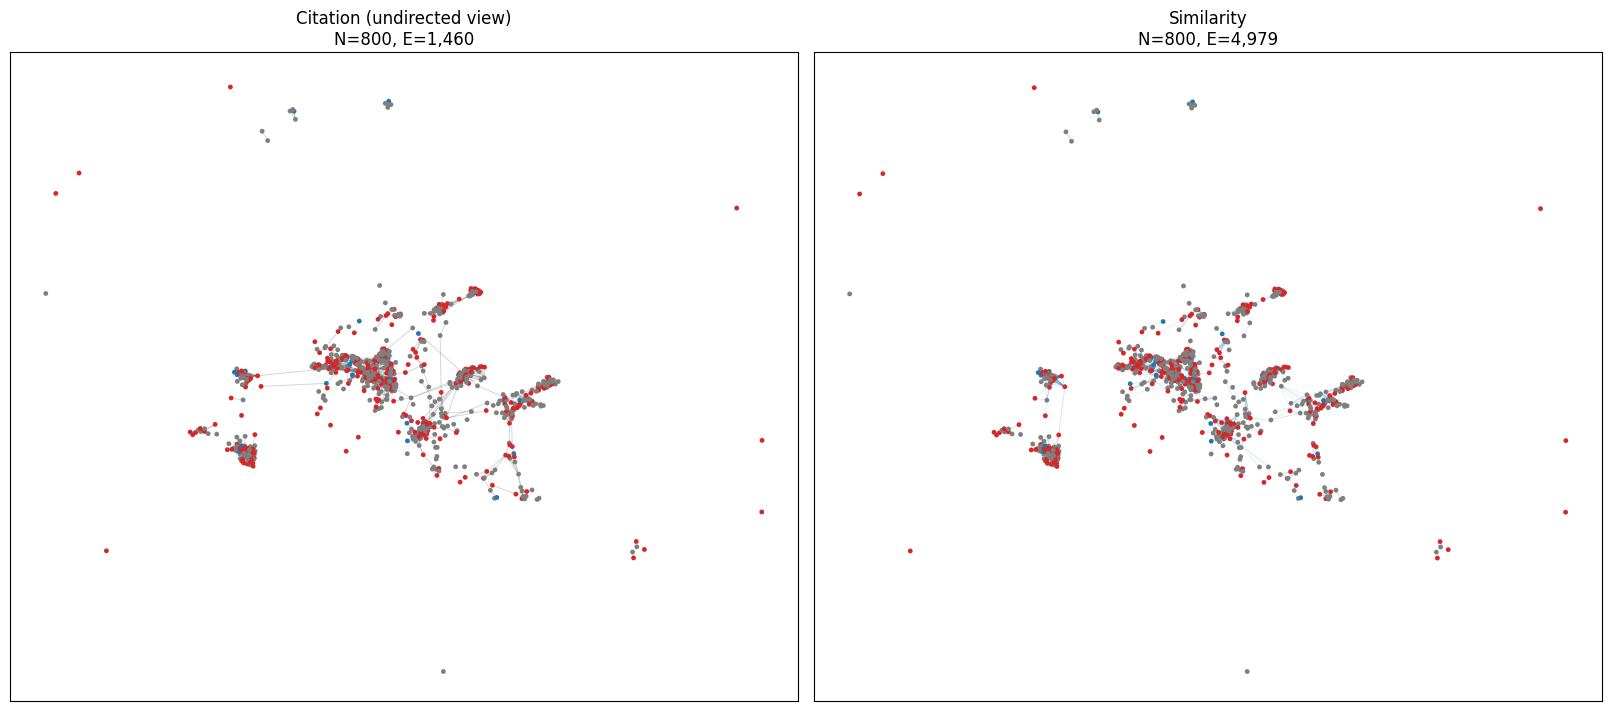

Saved: output/compare_networks/figs/01_shared_layout_small_multiples.png


In [15]:
# §9.1 Shared layout small multiples
print(f"[§9.1] N={len(nodes_v):,}, Ecite={Gc_v.number_of_edges():,}, Esim={Gs_v.number_of_edges():,}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

nodelist_v = list(G_union_v.nodes())
node_colors_v = _node_colors_from_country(nodelist_v, nodes_v)

safe_draw_network(
    Gc_v.to_undirected(),
    pos_v,
    axes[0],
    node_colors=node_colors_v,
    edge_alpha=0.25,
    edge_width_mode="uniform",
    title=f"Citation (undirected view)\nN={Gc_v.number_of_nodes():,}, E={Gc_v.number_of_edges():,}",
    node_size=12,
    edge_color="#444444",
    max_edges=int(MAX_EDGE_DRAW_MULTIPLIER * max(1, Gc_v.number_of_edges())),
)

safe_draw_network(
    Gs_v,
    pos_v,
    axes[1],
    node_colors=node_colors_v,
    edge_alpha=0.20,
    edge_width_mode="weight",
    title=f"Similarity\nN={Gs_v.number_of_nodes():,}, E={Gs_v.number_of_edges():,}",
    node_size=12,
    edge_color="#1f77b4",
    max_edges=int(MAX_EDGE_DRAW_MULTIPLIER * max(1, Gc_v.number_of_edges())),
)

fig_path = FIGS_DIR / "01_shared_layout_small_multiples.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## §9.2 Overlay / Multilayer

Purpose: directly inspect where citation and similarity links co-occur in one visual frame.
Citation and similarity use distinct edge styles; a light vertical offset is added to similarity nodes to mimic a multilayer view.

[§9.2] N=800, Ecite=1,460, Esim=4,979


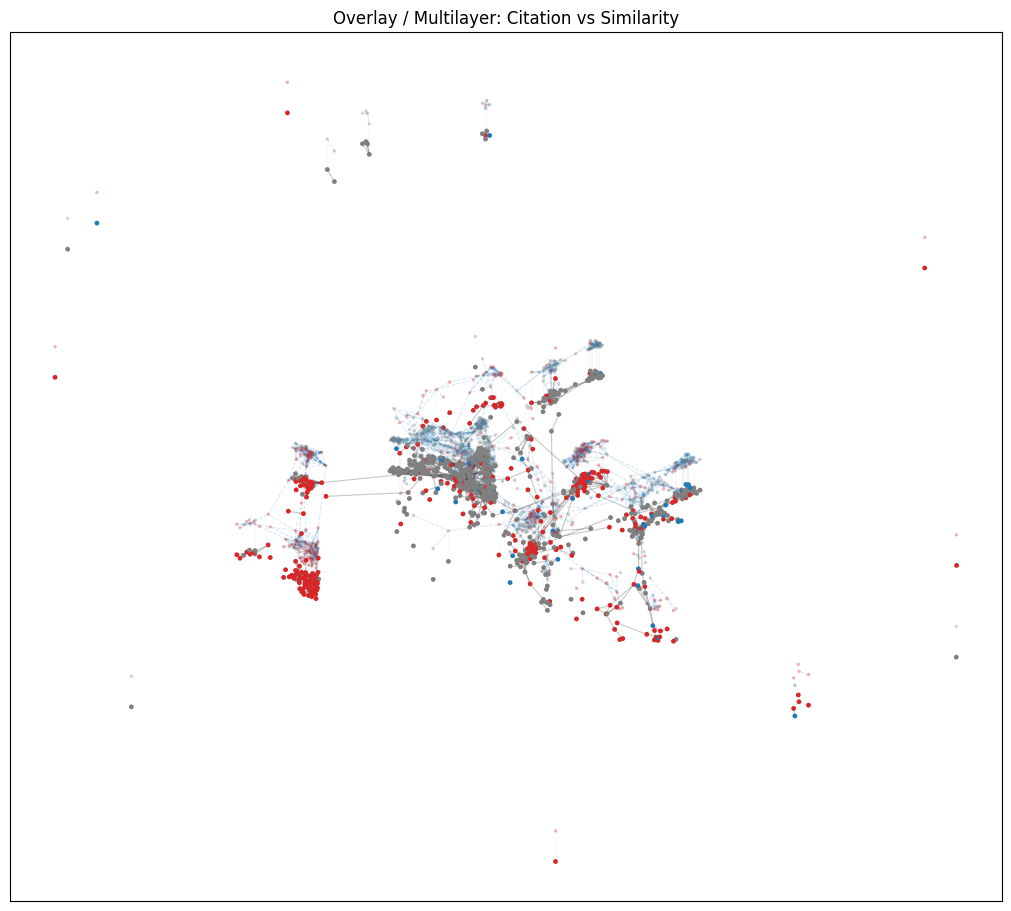

Saved: output/compare_networks/figs/02_overlay_multilayer.png


In [16]:
# §9.2 Overlay / Multilayer
print(f"[§9.2] N={len(nodes_v):,}, Ecite={Gc_v.number_of_edges():,}, Esim={Gs_v.number_of_edges():,}")

fig, ax = plt.subplots(figsize=(10, 9), constrained_layout=True)
ax.set_title("Overlay / Multilayer: Citation vs Similarity")
ax.set_xticks([])
ax.set_yticks([])

nodelist_v = list(G_union_v.nodes())
node_colors_v = _node_colors_from_country(nodelist_v, nodes_v)

# base layer (citation)
nx.draw_networkx_nodes(G_union_v, pos_v, nodelist=nodelist_v, node_color=node_colors_v, node_size=12, linewidths=0, ax=ax)

cite_edges_draw = list(Gc_v.to_undirected().edges())
if len(cite_edges_draw) > 0:
    max_c = int(MAX_EDGE_DRAW_MULTIPLIER * max(1, len(cite_edges_draw)))
    cite_edges_draw = cite_edges_draw[:max_c]
    nx.draw_networkx_edges(Gc_v.to_undirected(), pos_v, edgelist=cite_edges_draw, width=0.8, edge_color="#222222", alpha=0.25, ax=ax)

# similarity layer (slight y-offset)
pos_sim = {n: (xy[0], xy[1] + OVERLAY_LAYER_OFFSET) for n, xy in pos_v.items()}
sim_edges_draw = list(Gs_v.edges(data=True))
if len(sim_edges_draw) > 0:
    max_s = int(MAX_EDGE_DRAW_MULTIPLIER * max(1, len(cite_edges_draw))) if len(cite_edges_draw) > 0 else len(sim_edges_draw)
    sim_edges_draw = sim_edges_draw[:max_s]
    nx.draw_networkx_nodes(G_union_v, pos_sim, nodelist=nodelist_v, node_color=node_colors_v, node_size=6, alpha=0.35, linewidths=0, ax=ax)
    nx.draw_networkx_edges(
        Gs_v,
        pos_sim,
        edgelist=[(u, v) for u, v, _ in sim_edges_draw],
        width=0.7,
        edge_color="#1f77b4",
        alpha=0.18,
        style="dashed",
        ax=ax,
    )

    # projection lines for a subset of nodes
    proj_nodes = nodelist_v[: min(300, len(nodelist_v))]
    for n in proj_nodes:
        if n in pos_v and n in pos_sim:
            x0, y0 = pos_v[n]
            x1, y1 = pos_sim[n]
            ax.plot([x0, x1], [y0, y1], color="#999999", alpha=0.08, linewidth=0.5)

fig_path = FIGS_DIR / "02_overlay_multilayer.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## §9.3 Difference Graph (Only-cite / Only-sim / Both)

Purpose: decompose edge agreement into three disjoint sets to show where the two network definitions diverge.
All comparisons use normalized undirected edge tuples for fairness.

[§9.3] N=17,449, |E_cite|=48,230, |E_sim|=48,230, |both|=9,725
Saved: output/compare_networks/tables/edge_overlap_summary.csv


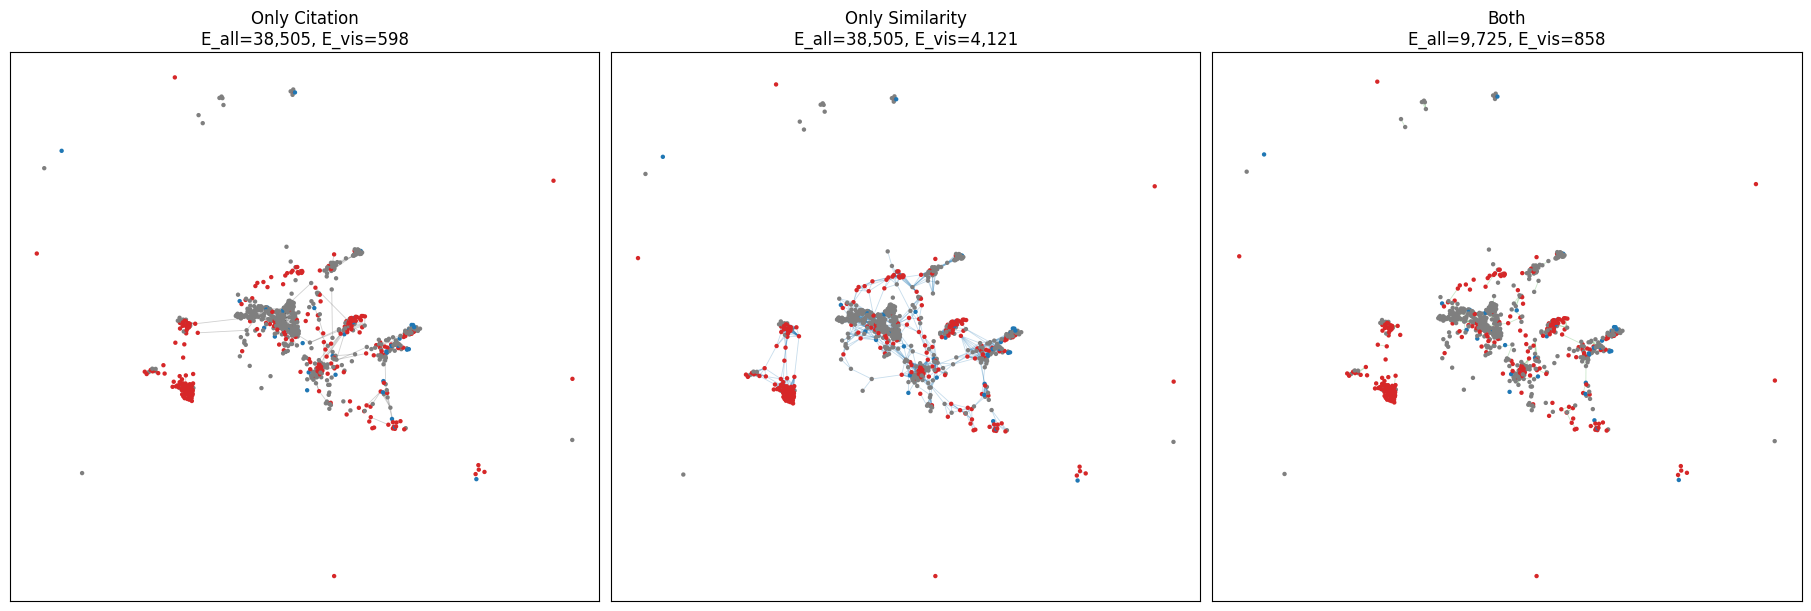

Saved: output/compare_networks/figs/03_difference_graph.png


In [17]:
# §9.3 Difference graph
E_cite = edge_set(Gc_h, directed=False)
E_sim = edge_set(Gs_cmp, directed=False)

only_cite = E_cite - E_sim
only_sim = E_sim - E_cite
both = E_cite & E_sim

print(f"[§9.3] N={len(node_set_h):,}, |E_cite|={len(E_cite):,}, |E_sim|={len(E_sim):,}, |both|={len(both):,}")

summary_df = pd.DataFrame([
    {"category": "only_cite", "count": len(only_cite)},
    {"category": "only_sim", "count": len(only_sim)},
    {"category": "both", "count": len(both)},
])
summary_df["ratio_over_union"] = summary_df["count"] / max(1, len(E_cite | E_sim))
summary_path = TABLES_DIR / "edge_overlap_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved: {summary_path}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

nodelist_v = list(G_union_v.nodes())
node_colors_v = _node_colors_from_country(nodelist_v, nodes_v)

for ax, eset, ttl, ecol in [
    (axes[0], only_cite, "Only Citation", "#444444"),
    (axes[1], only_sim, "Only Similarity", "#1f77b4"),
    (axes[2], both, "Both", "#2ca02c"),
]:
    eset_v = {(u, v) for (u, v) in eset if (u in nodelist_v and v in nodelist_v)}
    Gtmp = nx.Graph()
    Gtmp.add_nodes_from(nodelist_v)
    Gtmp.add_edges_from(list(eset_v))
    safe_draw_network(
        Gtmp,
        pos_v,
        ax,
        node_colors=node_colors_v,
        edge_alpha=0.25,
        edge_width_mode="uniform",
        title=f"{ttl}\nE_all={len(eset):,}, E_vis={len(eset_v):,}",
        node_size=10,
        edge_color=ecol,
        max_edges=int(MAX_EDGE_DRAW_MULTIPLIER * max(1, len(eset_v))),
    )

fig_path = FIGS_DIR / "03_difference_graph.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## §9.4 UpSet Plot (Edge set overlap)

Purpose: summarize overlap cardinalities compactly (`only_cite`, `only_sim`, `both`).
If `upsetplot` is unavailable, a bar-chart fallback is generated.

[§9.4] |only_cite|=38,505, |only_sim|=38,505, |both|=9,725
[info] upsetplot unavailable/fallback: No module named 'upsetplot'


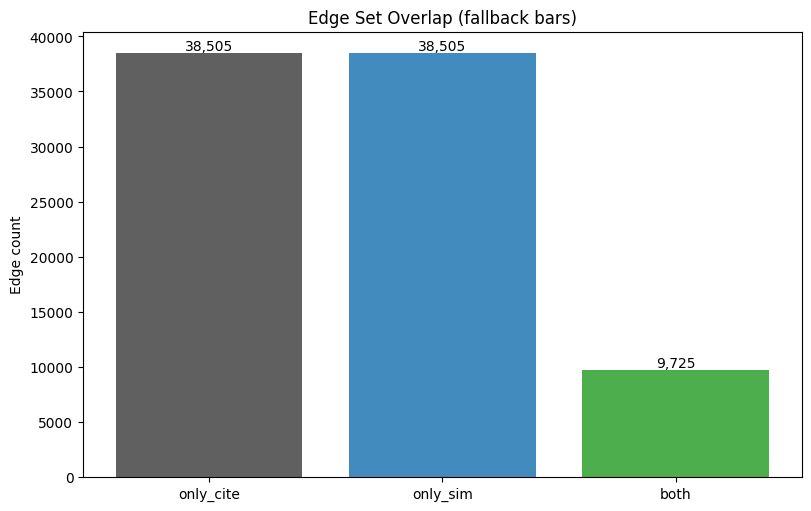

Saved: output/compare_networks/figs/04_upset_or_bars.png


In [18]:
# §9.4 UpSet (or fallback bars)
E_cite = edge_set(Gc_h, directed=False)
E_sim = edge_set(Gs_cmp, directed=False)
only_cite = E_cite - E_sim
only_sim = E_sim - E_cite
both = E_cite & E_sim

print(f"[§9.4] |only_cite|={len(only_cite):,}, |only_sim|={len(only_sim):,}, |both|={len(both):,}")

fig_path = FIGS_DIR / "04_upset_or_bars.png"

used_upset = False
try:
    from upsetplot import UpSet, from_memberships

    memberships = []
    for _ in only_cite:
        memberships.append(["Citation"])
    for _ in only_sim:
        memberships.append(["Similarity"])
    for _ in both:
        memberships.append(["Citation", "Similarity"])

    if len(memberships) == 0:
        raise RuntimeError("No edges for upset plot")

    data = from_memberships(memberships)
    fig = plt.figure(figsize=(10, 6))
    upset = UpSet(data, show_counts=True, sort_categories_by=None)
    upset.plot(fig=fig)
    plt.suptitle("Edge Set Overlap (Citation vs Similarity)")
    fig.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    used_upset = True
except Exception as e:
    print(f"[info] upsetplot unavailable/fallback: {e}")

if not used_upset:
    fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
    cats = ["only_cite", "only_sim", "both"]
    vals = [len(only_cite), len(only_sim), len(both)]
    colors = ["#444444", "#1f77b4", "#2ca02c"]
    bars = ax.bar(cats, vals, color=colors, alpha=0.85)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height(), f"{v:,}", ha="center", va="bottom", fontsize=10)
    ax.set_ylabel("Edge count")
    ax.set_title("Edge Set Overlap (fallback bars)")
    fig.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()

print(f"Saved: {fig_path}")

## §9.5 Adjacency Matrix Comparison (cite / sim / diff)

Purpose: compare meso-scale structures without node-link clutter by viewing aligned adjacency matrices.
Nodes are ordered by detected communities first, then topic (if available) or country.

[§9.5] N_adj=400, Ecite_adj=557, Esim_adj=2,161
Saved: output/compare_networks/tables/adj_node_order.csv


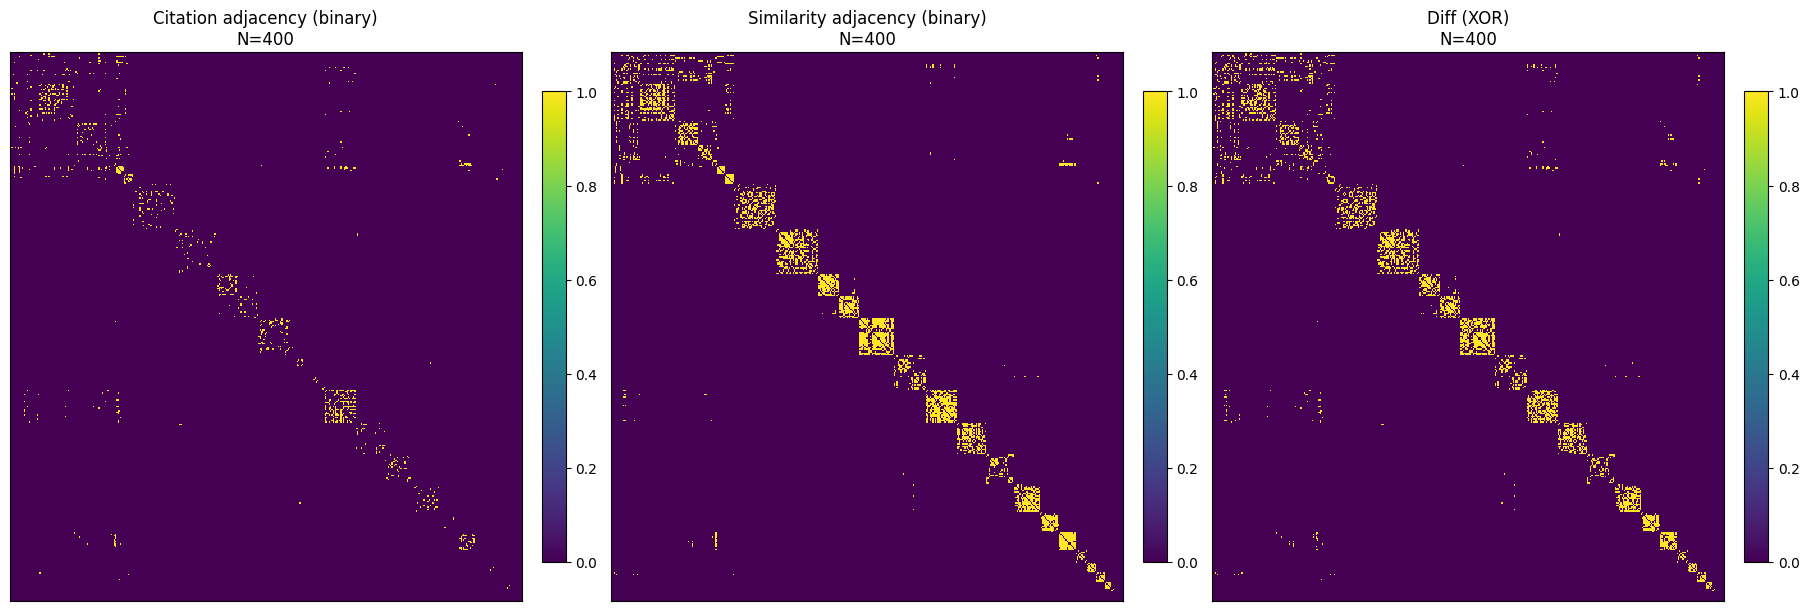

Saved: output/compare_networks/figs/05_adjacency_matrices.png


In [19]:
# §9.5 Adjacency matrices

# select matrix node subset
Gc_adj, Gs_adj, nodes_adj = choose_visual_subgraph(Gc_h, Gs_cmp, nodes_h, max_nodes=ADJ_N)
adj_nodes = nodes_adj["paper_id"].astype(str).tolist()

print(f"[§9.5] N_adj={len(adj_nodes):,}, Ecite_adj={Gc_adj.number_of_edges():,}, Esim_adj={Gs_adj.number_of_edges():,}")

# community-based ordering on union graph
G_union_adj = nx.Graph()
G_union_adj.add_nodes_from(adj_nodes)
G_union_adj.add_edges_from(Gc_adj.to_undirected().edges())
G_union_adj.add_edges_from(Gs_adj.edges())

comm_adj = community_detect(G_union_adj, method="greedy_modularity", max_nodes=COMM_MAX_NODES)
order_df = nodes_adj.copy()
order_df["paper_id"] = order_df["paper_id"].astype(str)
order_df["comm_id"] = order_df["paper_id"].map(comm_adj).fillna(-1).astype(int)

has_topic = ("topic" in order_df.columns) and (order_df["topic"].fillna(-1).astype(int) != -1).any()
if has_topic:
    order_df = order_df.sort_values(["comm_id", "topic", "country_norm", "paper_id"], kind="stable")
else:
    print("[§9.5] topic not available, sorting by community + country")
    order_df = order_df.sort_values(["comm_id", "country_norm", "paper_id"], kind="stable")

adj_order = order_df["paper_id"].tolist()
order_out = order_df.reset_index(drop=True).copy()
order_out.insert(0, "order", np.arange(1, len(order_out) + 1))
order_path = TABLES_DIR / "adj_node_order.csv"
order_out.to_csv(order_path, index=False)
print(f"Saved: {order_path}")

A_cite = nx.to_numpy_array(Gc_adj.to_undirected(), nodelist=adj_order, weight=None)
A_sim_w = nx.to_numpy_array(Gs_adj, nodelist=adj_order, weight="weight")
A_sim = (A_sim_w > 0).astype(int)
A_cite = (A_cite > 0).astype(int)
A_diff = np.logical_xor(A_cite, A_sim).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
for ax, mat, ttl in [
    (axes[0], A_cite, "Citation adjacency (binary)"),
    (axes[1], A_sim, "Similarity adjacency (binary)"),
    (axes[2], A_diff, "Diff (XOR)"),
]:
    im = ax.imshow(mat, cmap="viridis", interpolation="nearest", aspect="auto")
    ax.set_title(f"{ttl}\nN={mat.shape[0]:,}")
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig_path = FIGS_DIR / "05_adjacency_matrices.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## §9.6 Community Alignment Alluvial / Sankey

Purpose: quantify how citation communities map onto similarity communities.
Contingency counts are exported and visualized as Sankey/alluvial flows.

In [20]:
# §9.6 Community alignment Sankey
Gc_comm = Gc_h.to_undirected()
Gs_comm = Gs_cmp.copy()

print(f"[§9.6] N={len(node_set_h):,}, Ecite={Gc_comm.number_of_edges():,}, Esim={Gs_comm.number_of_edges():,}")

comm_cite = community_detect(Gc_comm, method="greedy_modularity", max_nodes=COMM_MAX_NODES)
comm_sim = community_detect(Gs_comm, method="greedy_modularity", max_nodes=COMM_MAX_NODES)

nodes_for_comm = sorted(list(node_set_h))
align_df = build_contingency(comm_cite, comm_sim, nodes_for_comm)
align_df = align_df.rename(columns={"comm_a": "comm_cite", "comm_b": "comm_sim"})

align_path = TABLES_DIR / "community_alignment.csv"
align_df.to_csv(align_path, index=False)
print(f"Saved: {align_path}")

if len(align_df) == 0:
    fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
    ax.text(0.5, 0.5, "No community alignment data", ha="center", va="center", transform=ax.transAxes)
    ax.set_axis_off()
    fig_path = FIGS_DIR / "06_alluvial_sankey.png"
    fig.savefig(fig_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fig_path}")
else:
    used_plotly = False
    try:
        import plotly.graph_objects as go

        top_df = align_df.sort_values("count", ascending=False).head(200).copy()
        left_labels = [f"C{int(c)}" for c in sorted(top_df["comm_cite"].unique())]
        right_labels = [f"S{int(c)}" for c in sorted(top_df["comm_sim"].unique())]
        labels = left_labels + right_labels
        idx = {lab: i for i, lab in enumerate(labels)}

        source = [idx[f"C{int(c)}"] for c in top_df["comm_cite"]]
        target = [idx[f"S{int(c)}"] for c in top_df["comm_sim"]]
        value = top_df["count"].astype(int).tolist()

        fig = go.Figure(data=[go.Sankey(
            node=dict(pad=12, thickness=12, label=labels),
            link=dict(source=source, target=target, value=value),
        )])
        fig.update_layout(title_text="Community Alignment: Citation -> Similarity", font_size=10)

        html_path = FIGS_DIR / "06_alluvial_sankey.html"
        fig.write_html(str(html_path), include_plotlyjs="cdn")
        print(f"Saved: {html_path}")
        used_plotly = True
    except Exception as e:
        print(f"[info] plotly sankey unavailable/fallback: {e}")

    if not used_plotly:
        from matplotlib.sankey import Sankey

        top_c = int(align_df.groupby("comm_cite")["count"].sum().sort_values(ascending=False).index[0])
        flow_df = align_df[align_df["comm_cite"] == top_c].sort_values("count", ascending=False).head(8)
        total = int(flow_df["count"].sum())

        fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
        if total <= 0:
            ax.text(0.5, 0.5, "No flows to draw", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
        else:
            flows = [total] + [-int(v) for v in flow_df["count"].tolist()]
            labels = [f"C{top_c}"] + [f"S{int(s)}" for s in flow_df["comm_sim"].tolist()]
            orientations = [0] + [1] * len(flow_df)
            sankey = Sankey(ax=ax, scale=1.0 / total, format="%d")
            sankey.add(flows=flows, labels=labels, orientations=orientations)
            sankey.finish()
            ax.set_title("Community Alignment (fallback Sankey, top source community)")

        png_path = FIGS_DIR / "06_alluvial_sankey.png"
        fig.savefig(png_path, dpi=180, bbox_inches="tight")
        plt.show()
        print(f"Saved: {png_path}")

[§9.6] N=17,449, Ecite=48,230, Esim=48,230
Saved: output/compare_networks/tables/community_alignment.csv
Saved: output/compare_networks/figs/06_alluvial_sankey.html


## §9.7 Node-level Rank–Rank / Scatter (Centrality vs Centrality)

Purpose: compare node importance under citation and similarity definitions.
Scatter highlights agreement/disagreement regimes using top-10% quadrant reference lines.

[§9.7] N=17,449, Ecite=48,275, Esim=48,230
Saved: output/compare_networks/tables/node_centrality_compare.csv


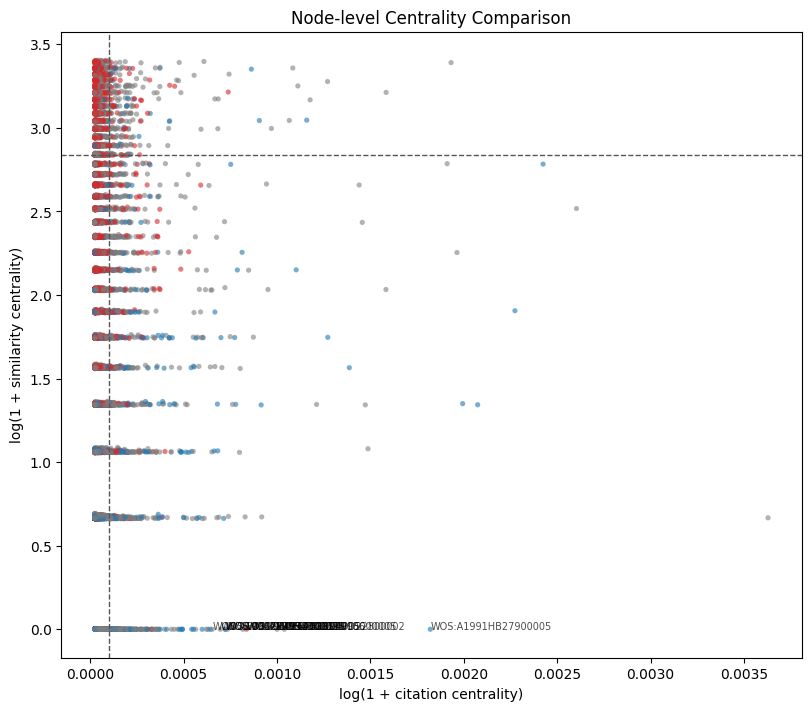

Saved: output/compare_networks/figs/07_rank_rank_scatter.png


In [21]:
# §9.7 Rank-rank / scatter
all_nodes = sorted(list(node_set_h))
print(f"[§9.7] N={len(all_nodes):,}, Ecite={Gc_h.number_of_edges():,}, Esim={Gs_cmp.number_of_edges():,}")

# citation score
score_cite = {}
if Gc_h.number_of_nodes() > 0 and Gc_h.number_of_edges() > 0:
    try:
        score_cite = nx.pagerank(Gc_h)
    except Exception:
        score_cite = {n: float(v) for n, v in Gc_h.in_degree()}
else:
    score_cite = {n: 0.0 for n in all_nodes}

# similarity score
score_sim = dict(Gs_cmp.degree(weight="weight")) if Gs_cmp.number_of_nodes() > 0 else {}

rows = []
for n in all_nodes:
    rows.append({
        "paper_id": n,
        "score_cite": float(score_cite.get(n, 0.0)),
        "score_sim": float(score_sim.get(n, 0.0)),
    })

scores_df = pd.DataFrame(rows)
if len(scores_df) == 0:
    scores_df = pd.DataFrame(columns=["paper_id", "score_cite", "score_sim"])

scores_df["rank_cite"] = scores_df["score_cite"].rank(ascending=False, method="min")
scores_df["rank_sim"] = scores_df["score_sim"].rank(ascending=False, method="min")

meta_cols = nodes_h[["paper_id", "country", "country_norm", "year", "topic"]].copy()
scores_df = scores_df.merge(meta_cols, on="paper_id", how="left")

out_path = TABLES_DIR / "node_centrality_compare.csv"
scores_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

fig, ax = plt.subplots(figsize=(8, 7), constrained_layout=True)
if len(scores_df) == 0:
    ax.text(0.5, 0.5, "No nodes to plot", ha="center", va="center", transform=ax.transAxes)
else:
    x = np.log1p(scores_df["score_cite"].astype(float).values)
    y = np.log1p(scores_df["score_sim"].astype(float).values)
    color_map = {"CN": "#d62728", "US": "#1f77b4", "OTHER": "#7f7f7f"}
    c = [color_map.get(v, "#7f7f7f") for v in scores_df["country_norm"].fillna("OTHER")]

    ax.scatter(x, y, s=14, alpha=0.6, c=c, linewidths=0)

    x_thr = np.quantile(x, 0.9) if len(x) else 0
    y_thr = np.quantile(y, 0.9) if len(y) else 0
    ax.axvline(x_thr, color="#555555", linestyle="--", linewidth=1)
    ax.axhline(y_thr, color="#555555", linestyle="--", linewidth=1)

    # annotate a few outliers
    scores_df["delta"] = np.abs(scores_df["rank_cite"] - scores_df["rank_sim"])
    top_out = scores_df.sort_values("delta", ascending=False).head(10)
    for _, r in top_out.iterrows():
        ax.text(np.log1p(r["score_cite"]), np.log1p(r["score_sim"]), str(r["paper_id"]), fontsize=7, alpha=0.7)

ax.set_xlabel("log(1 + citation centrality)")
ax.set_ylabel("log(1 + similarity centrality)")
ax.set_title("Node-level Centrality Comparison")

fig_path = FIGS_DIR / "07_rank_rank_scatter.png"
fig.savefig(fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")

## §9.8 Similarity→Citation PR Curve / Top-K Hit

Purpose: treat citation edges as reference truth and test how well high-similarity edges recover them.
We report precision@K, recall@K, PR curve, and hit@K trends.

[§9.8] N=17,449, |E_cite_truth|=48,230, |sim_eval_edges|=97,167, Ks=[100, 200, 500, 1000, 2000, 5000, 10000, 97167]
Saved: output/compare_networks/tables/pr_curve_points.csv


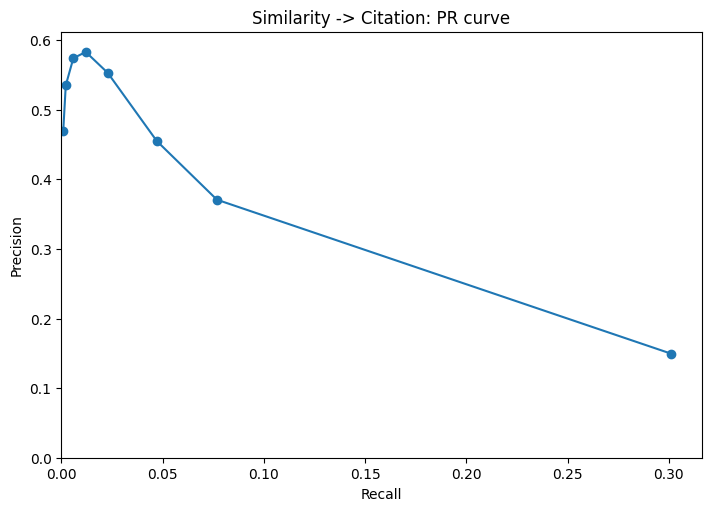

Saved: output/compare_networks/figs/08_pr_curve.png


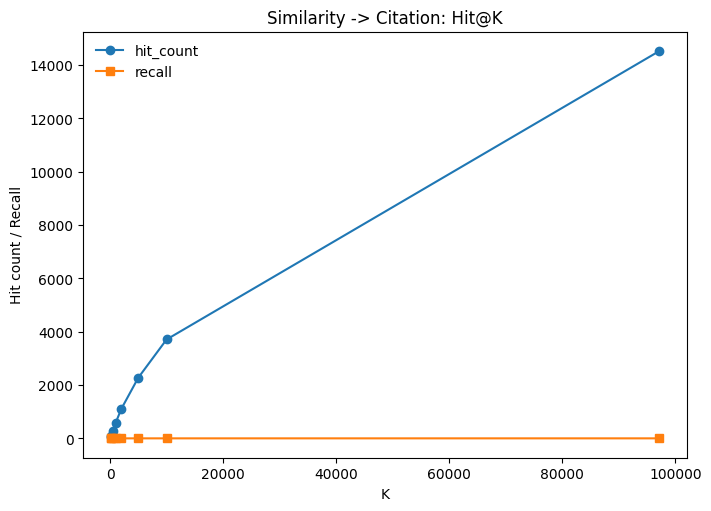

Saved: output/compare_networks/figs/08_hit_at_k.png


In [22]:
# §9.8 PR curve / Hit@K (sim predicts cite)
E_cite_truth = edge_set(Gc_h, directed=False)
sim_eval = sim_edges_h[["src", "dst", "weight"]].copy() if len(sim_edges_h) > 0 else pd.DataFrame(columns=["src", "dst", "weight"])

max_k_auto = len(sim_eval)
ks = sorted(set([k for k in PR_KS_BASE if k <= max_k_auto]))
if max_k_auto > 0 and (len(ks) == 0 or ks[-1] != max_k_auto):
    ks.append(max_k_auto)

print(f"[§9.8] N={len(node_set_h):,}, |E_cite_truth|={len(E_cite_truth):,}, |sim_eval_edges|={len(sim_eval):,}, Ks={ks[:8]}{'...' if len(ks)>8 else ''}")

pr_df = pr_curve_from_similarity(E_cite_truth, sim_eval, ks)
pr_path = TABLES_DIR / "pr_curve_points.csv"
pr_df.to_csv(pr_path, index=False)
print(f"Saved: {pr_path}")

# PR curve
fig1, ax1 = plt.subplots(figsize=(7, 5), constrained_layout=True)
if len(pr_df) == 0:
    ax1.text(0.5, 0.5, "No PR points (empty sim edges)", ha="center", va="center", transform=ax1.transAxes)
else:
    ax1.plot(pr_df["recall"], pr_df["precision"], marker="o", linewidth=1.5)
    ax1.set_xlim(0, min(1.0, max(0.01, pr_df["recall"].max() * 1.05)))
    ax1.set_ylim(0, min(1.0, max(0.01, pr_df["precision"].max() * 1.05)))
ax1.set_xlabel("Recall")
ax1.set_ylabel("Precision")
ax1.set_title("Similarity -> Citation: PR curve")

fig1_path = FIGS_DIR / "08_pr_curve.png"
fig1.savefig(fig1_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig1_path}")

# Hit@K
fig2, ax2 = plt.subplots(figsize=(7, 5), constrained_layout=True)
if len(pr_df) == 0:
    ax2.text(0.5, 0.5, "No Hit@K points", ha="center", va="center", transform=ax2.transAxes)
else:
    ax2.plot(pr_df["K"], pr_df["hit_count"], marker="o", label="hit_count")
    ax2.plot(pr_df["K"], pr_df["recall"], marker="s", label="recall")
    ax2.legend(frameon=False)
ax2.set_xlabel("K")
ax2.set_ylabel("Hit count / Recall")
ax2.set_title("Similarity -> Citation: Hit@K")

fig2_path = FIGS_DIR / "08_hit_at_k.png"
fig2.savefig(fig2_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {fig2_path}")

In [23]:
# §9 Final artifact check (non-fatal)
required_figs = [
    FIGS_DIR / "01_shared_layout_small_multiples.png",
    FIGS_DIR / "02_overlay_multilayer.png",
    FIGS_DIR / "03_difference_graph.png",
    FIGS_DIR / "04_upset_or_bars.png",
    FIGS_DIR / "05_adjacency_matrices.png",
    FIGS_DIR / "07_rank_rank_scatter.png",
    FIGS_DIR / "08_pr_curve.png",
    FIGS_DIR / "08_hit_at_k.png",
]

# sankey may be html or png
sankey_html = FIGS_DIR / "06_alluvial_sankey.html"
sankey_png = FIGS_DIR / "06_alluvial_sankey.png"

print("\n§9 artifact existence check:")
for p in required_figs:
    print(f"  {'OK' if p.exists() else 'MISSING'}  {p}")
print(f"  {'OK' if (sankey_html.exists() or sankey_png.exists()) else 'MISSING'}  06_alluvial_sankey.(html|png)")

table_files = sorted(TABLES_DIR.glob("*.csv"))
print(f"\nCSV tables in {TABLES_DIR}: {len(table_files)}")
for p in table_files:
    print(f"  - {p.name}")


§9 artifact existence check:
  OK  output/compare_networks/figs/01_shared_layout_small_multiples.png
  OK  output/compare_networks/figs/02_overlay_multilayer.png
  OK  output/compare_networks/figs/03_difference_graph.png
  OK  output/compare_networks/figs/04_upset_or_bars.png
  OK  output/compare_networks/figs/05_adjacency_matrices.png
  OK  output/compare_networks/figs/07_rank_rank_scatter.png
  OK  output/compare_networks/figs/08_pr_curve.png
  OK  output/compare_networks/figs/08_hit_at_k.png
  OK  06_alluvial_sankey.(html|png)

CSV tables in output/compare_networks/tables: 38
  - adj_node_order.csv
  - beta_win3.csv
  - beta_win3_fixed.csv
  - beta_win3_point.csv
  - beta_win3_twopair.csv
  - beta_win5.csv
  - beta_win5_fixed.csv
  - beta_win5_point.csv
  - beta_win5_twopair.csv
  - beta_yearly.csv
  - beta_yearly_fixed.csv
  - beta_yearly_point.csv
  - beta_yearly_twopair.csv
  - coef_bootstrap_ci.csv
  - coef_bootstrap_draws.csv
  - community_alignment.csv
  - edge_overlap_summar

## §9.9 Citation vs Similarity — Time-Consistent Evaluation

Time filtering is needed because citation is directional and time-ordered, while similarity edges are often symmetric and may connect to future papers.
Without filtering, similarity-based retrieval can leak future information and overstate alignment with citation links.
Here we enforce `year_dst <= year_src` (with optional same-year/window controls), then compare baseline vs time-consistent PR/Hit@K.
This makes overlap and ranking metrics more interpretable for causal/forecast-like reading.

In [24]:
# §9.9 Config (time consistency)
from pathlib import Path
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ENABLE_TIME_FILTER = True
ALLOW_SAME_YEAR = True
TIME_WINDOW = None      # e.g., 10 means (year_src - year_dst) <= 10 and year_dst <= year_src
DROP_NA_YEAR = False

TOPK_LIST = [100, 200, 500, 1000, 2000]

FIGS_DIR = Path("output/compare_networks/figs")
TABLES_DIR = Path("output/compare_networks/tables")
FIGS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("§9.9 config loaded")
print({
    "ENABLE_TIME_FILTER": ENABLE_TIME_FILTER,
    "ALLOW_SAME_YEAR": ALLOW_SAME_YEAR,
    "TIME_WINDOW": TIME_WINDOW,
    "DROP_NA_YEAR": DROP_NA_YEAR,
    "TOPK_LIST": TOPK_LIST,
})

§9.9 config loaded
{'ENABLE_TIME_FILTER': True, 'ALLOW_SAME_YEAR': True, 'TIME_WINDOW': None, 'DROP_NA_YEAR': False, 'TOPK_LIST': [100, 200, 500, 1000, 2000]}


In [25]:
# §9.9 Helper functions

def make_sim_edges_with_attrs(edges_df, df) -> pd.DataFrame:
    """
    Build similarity edge table with attrs.
    Output columns: src_pid, dst_pid, sim, year_src, year_dst
    """
    if edges_df is None or len(edges_df) == 0:
        return pd.DataFrame(columns=["src_pid", "dst_pid", "sim", "year_src", "year_dst"])

    local_df = df.copy()
    local_df = local_df.reset_index(drop=True)
    local_df["paper_id"] = local_df["paper_id"].astype(str)
    local_df["year"] = pd.to_numeric(local_df["year"], errors="coerce")

    id_to_pid = dict(enumerate(local_df["paper_id"].tolist()))
    id_to_year = dict(enumerate(local_df["year"].tolist()))
    pid_to_year = dict(zip(local_df["paper_id"].tolist(), local_df["year"].tolist()))

    e = edges_df.copy()

    # case A: index-based i/j
    if {"i", "j"}.issubset(e.columns):
        out = pd.DataFrame()
        out["src_pid"] = e["i"].map(id_to_pid)
        out["dst_pid"] = e["j"].map(id_to_pid)
        out["sim"] = pd.to_numeric(e["sim"] if "sim" in e.columns else e.get("weight", 1.0), errors="coerce").fillna(0.0)
        out["year_src"] = e["i"].map(id_to_year)
        out["year_dst"] = e["j"].map(id_to_year)
    else:
        # case B: paper-id based src/dst
        src_col = next((c for c in ["src_pid", "src", "source", "u", "paper_id_i", "src_paper_id"] if c in e.columns), None)
        dst_col = next((c for c in ["dst_pid", "dst", "target", "v", "paper_id_j", "dst_paper_id"] if c in e.columns), None)
        if src_col is None or dst_col is None:
            return pd.DataFrame(columns=["src_pid", "dst_pid", "sim", "year_src", "year_dst"])
        out = pd.DataFrame()
        out["src_pid"] = e[src_col].astype(str)
        out["dst_pid"] = e[dst_col].astype(str)
        out["sim"] = pd.to_numeric(e["sim"] if "sim" in e.columns else e.get("weight", e.get("similarity", 1.0)), errors="coerce").fillna(0.0)
        out["year_src"] = out["src_pid"].map(pid_to_year)
        out["year_dst"] = out["dst_pid"].map(pid_to_year)

    out = out.dropna(subset=["src_pid", "dst_pid"]).copy()
    out["src_pid"] = out["src_pid"].astype(str)
    out["dst_pid"] = out["dst_pid"].astype(str)
    out = out[out["src_pid"] != out["dst_pid"]]

    # canonical undirected pair (keep max sim)
    out["u"] = out[["src_pid", "dst_pid"]].min(axis=1)
    out["v"] = out[["src_pid", "dst_pid"]].max(axis=1)
    out = out.sort_values("sim", ascending=False).drop_duplicates(["u", "v"]).reset_index(drop=True)

    # align year columns to canonical direction u->v
    out["year_u"] = out.apply(lambda r: r["year_src"] if r["src_pid"] == r["u"] else r["year_dst"], axis=1)
    out["year_v"] = out.apply(lambda r: r["year_dst"] if r["src_pid"] == r["u"] else r["year_src"], axis=1)

    out2 = out[["u", "v", "sim", "year_u", "year_v"]].copy()
    out2 = out2.rename(columns={"u": "src_pid", "v": "dst_pid", "year_u": "year_src", "year_v": "year_dst"})
    return out2[["src_pid", "dst_pid", "sim", "year_src", "year_dst"]].copy()


def orient_sim_by_year(sim_df, allow_same_year=True, drop_na_year=False, time_window=None) -> pd.DataFrame:
    """
    Convert undirected sim edges into directed later->earlier edges.
    Output columns: src_pid, dst_pid, sim, year_src, year_dst
    """
    cols = ["src_pid", "dst_pid", "sim", "year_src", "year_dst"]
    if sim_df is None or len(sim_df) == 0:
        return pd.DataFrame(columns=cols)

    rows = []
    for _, r in sim_df.iterrows():
        a, b = str(r["src_pid"]), str(r["dst_pid"])
        ya = pd.to_numeric(r["year_src"], errors="coerce")
        yb = pd.to_numeric(r["year_dst"], errors="coerce")
        s = float(r.get("sim", 0.0))

        if pd.isna(ya) or pd.isna(yb):
            if drop_na_year:
                continue
            # keep both directions when years unknown
            rows.append((a, b, s, ya, yb))
            rows.append((b, a, s, yb, ya))
            continue

        if ya > yb:
            if (time_window is None) or ((ya - yb) <= time_window):
                rows.append((a, b, s, ya, yb))
        elif yb > ya:
            if (time_window is None) or ((yb - ya) <= time_window):
                rows.append((b, a, s, yb, ya))
        else:
            # same year
            if allow_same_year:
                rows.append((a, b, s, ya, yb))
                rows.append((b, a, s, yb, ya))

    out = pd.DataFrame(rows, columns=cols)
    if len(out) == 0:
        return out

    out["sim"] = pd.to_numeric(out["sim"], errors="coerce").fillna(0.0)
    out = out.sort_values("sim", ascending=False).drop_duplicates(["src_pid", "dst_pid"]).reset_index(drop=True)
    return out


def build_edge_set_directed(df_edges, src_col, dst_col):
    if df_edges is None or len(df_edges) == 0:
        return set()
    return set(zip(df_edges[src_col].astype(str), df_edges[dst_col].astype(str)))


def pr_hit_curves(sim_dir_df_sorted, cite_edge_set, topk_list):
    cols = ["K", "precision", "recall", "hit_count", "total_true", "total_pred"]
    if sim_dir_df_sorted is None or len(sim_dir_df_sorted) == 0:
        return pd.DataFrame(columns=cols)

    x = sim_dir_df_sorted[["src_pid", "dst_pid", "sim"]].copy()
    x["src_pid"] = x["src_pid"].astype(str)
    x["dst_pid"] = x["dst_pid"].astype(str)
    x = x.sort_values("sim", ascending=False).drop_duplicates(["src_pid", "dst_pid"]).reset_index(drop=True)

    max_k = len(x)
    ks = sorted(set(int(k) for k in topk_list if int(k) > 0 and int(k) <= max_k))
    if max_k > 0 and (len(ks) == 0 or ks[-1] != max_k):
        ks.append(max_k)

    total_true = max(len(cite_edge_set), 1)
    flags = np.array([(s, d) in cite_edge_set for s, d in zip(x["src_pid"], x["dst_pid"])], dtype=int)
    cum_hits = np.cumsum(flags)

    rows = []
    for k in ks:
        hits = int(cum_hits[k - 1])
        rows.append({
            "K": int(k),
            "precision": float(hits / k),
            "recall": float(hits / total_true),
            "hit_count": int(hits),
            "total_true": int(total_true),
            "total_pred": int(k),
        })
    return pd.DataFrame(rows, columns=cols)


def per_node_recall_at_k(sim_neighbors, cite_adj, years, K, allow_same_year=True, time_window=None):
    """
    sim_neighbors: dict[src] -> list[(dst, sim)] (can be from undirected edges expanded both ways)
    cite_adj: dict[src] -> set(dst)
    years: dict[node] -> year
    """
    rows = []
    all_src = sorted(set(cite_adj.keys()) | set(sim_neighbors.keys()))

    for src in all_src:
        y_src = pd.to_numeric(years.get(src, np.nan), errors="coerce")
        cand = sim_neighbors.get(src, [])

        filtered = []
        for dst, sim in cand:
            y_dst = pd.to_numeric(years.get(dst, np.nan), errors="coerce")

            if pd.isna(y_src) or pd.isna(y_dst):
                # keep unknown years; global switch handled in orient stage
                pass
            else:
                if y_dst > y_src:
                    continue
                if (not allow_same_year) and (y_dst == y_src):
                    continue
                if (time_window is not None) and ((y_src - y_dst) > time_window):
                    continue

            filtered.append((dst, float(sim)))

        filtered = sorted(filtered, key=lambda t: t[1], reverse=True)
        topk = [d for d, _ in filtered[:K]]

        truth = cite_adj.get(src, set())
        truth_n = len(truth)
        hit_n = len(set(topk) & set(truth))
        rec = (hit_n / truth_n) if truth_n > 0 else np.nan

        rows.append({
            "src_pid": src,
            "year_src": y_src,
            "K": int(K),
            "cite_out_degree": int(truth_n),
            "hit_count": int(hit_n),
            "recall_at_k": rec,
            "cand_count_after_filter": int(len(filtered)),
        })

    return pd.DataFrame(rows)

print("§9.9 helper functions ready")

§9.9 helper functions ready


[nodes] using in-memory df
[nodes] source=in_memory:df, n=25,794
[sim] using in-memory edges_raw
[sim] source=in_memory:edges_raw, undirected edges=149,705
[cite] loaded from citation_results edges, n=49,084
[diag] citation time violation rate P(year_src < year_dst) = 0.0007 on 49,084 valid edges
[diag] sim directed keep ratio after time filter = 0.5481 (164,103/299,410)
[overlap] baseline directed overlap=14,557 / 299,410
[overlap] time-consistent directed overlap=14,542 / 164,103
Saved: output/compare_networks/tables/pr_curve_points_baseline.csv
Saved: output/compare_networks/tables/pr_curve_points_time.csv


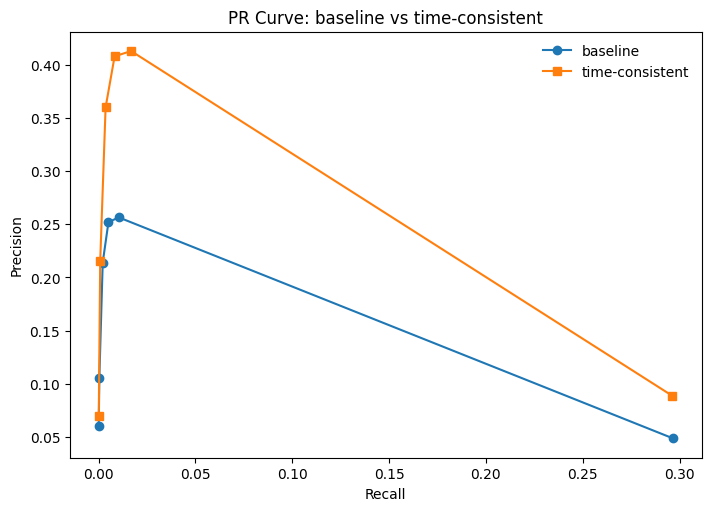

Saved: output/compare_networks/figs/pr_curve_time.png


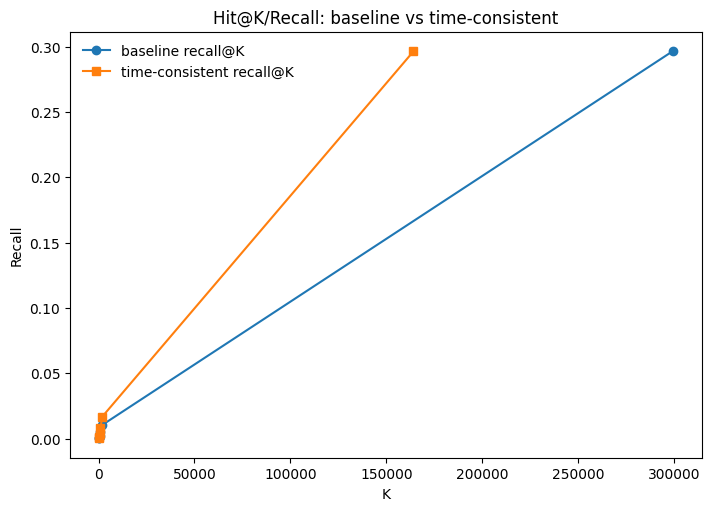

Saved: output/compare_networks/figs/hit_at_k_time.png
Saved: output/compare_networks/tables/per_node_recall_time.csv
Saved: output/compare_networks/tables/per_node_recall_time_summary.csv


In [26]:
# §9.9 Run time-consistent evaluation and save outputs

def _read_any_table(path):
    if path is None:
        return None
    p = Path(path)
    cands = [p]
    if p.suffix.lower() == ".parquet":
        cands.append(p.with_suffix(".csv"))
    elif p.suffix.lower() == ".csv":
        cands.append(p.with_suffix(".parquet"))
    for c in cands:
        if c.exists():
            try:
                return pd.read_parquet(c) if c.suffix.lower() == ".parquet" else pd.read_csv(c)
            except Exception as e:
                print(f"[warn] read failed {c}: {e}")
    return None


def _normalize_nodes_df(df_like):
    if df_like is None or len(df_like) == 0:
        return pd.DataFrame(columns=["paper_id", "year", "country", "topic"])
    x = df_like.copy()

    if "paper_id" not in x.columns:
        if x.index.name == "paper_id":
            x = x.reset_index()
        else:
            x = x.reset_index(drop=True)
            x["paper_id"] = [f"paper_{i}" for i in range(len(x))]

    if "year" not in x.columns:
        x["year"] = pd.NA
    x["year"] = pd.to_numeric(x["year"], errors="coerce")

    if "country" not in x.columns:
        if "country2" in x.columns:
            x["country"] = x["country2"]
        elif "country_group" in x.columns:
            x["country"] = x["country_group"]
        else:
            x["country"] = "OTHER"

    if "topic" not in x.columns:
        for c in ["topic_reduced", "topic_reassign"]:
            if c in x.columns:
                x["topic"] = pd.to_numeric(x[c], errors="coerce")
                break
        if "topic" not in x.columns:
            x["topic"] = -1
    x["topic"] = pd.to_numeric(x["topic"], errors="coerce").fillna(-1).astype(int)

    x["paper_id"] = x["paper_id"].astype(str)
    x["country"] = x["country"].fillna("OTHER").astype(str)
    return x[["paper_id", "year", "country", "topic"]].drop_duplicates("paper_id").reset_index(drop=True)


def _load_similarity_input():
    for nm in ["edges_df", "edges_raw", "knn_edges_df", "edges"]:
        if nm in globals() and isinstance(globals()[nm], pd.DataFrame):
            e = globals()[nm]
            if len(e) > 0 and ({"i", "j"}.issubset(e.columns) or {"src", "dst"}.issubset(e.columns)):
                print(f"[sim] using in-memory {nm}")
                return e.copy(), f"in_memory:{nm}"

    for p in ["output/graph/edges.parquet", "output/knn_results/edges.parquet", "output/graph/edges.csv", "output/knn_results/edges.csv"]:
        t = _read_any_table(p)
        if t is not None:
            print(f"[sim] loaded from {p}")
            return t, f"file:{p}"

    return pd.DataFrame(), "empty"


def _load_nodes_input():
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame) and "paper_id" in globals()["df"].columns:
        print("[nodes] using in-memory df")
        return globals()["df"].copy(), "in_memory:df"
    if "nodes" in globals() and isinstance(globals()["nodes"], pd.DataFrame) and "paper_id" in globals()["nodes"].columns:
        print("[nodes] using in-memory nodes")
        return globals()["nodes"].copy(), "in_memory:nodes"

    for p in ["output/graph/nodes.parquet", "output/citation_results/nodes_raw.parquet"]:
        t = _read_any_table(p)
        if t is not None:
            print(f"[nodes] loaded from {p}")
            return t, f"file:{p}"

    return pd.DataFrame(), "empty"


def _load_citation_edges(nodes_df):
    c = _read_any_table("output/citation_results/edges.parquet")
    if c is None:
        c = _read_any_table("output/citation_results/edges.csv")
    if c is not None and len(c) > 0:
        src_col = next((k for k in ["src_paper_id", "src", "source", "paper_id_src"] if k in c.columns), None)
        dst_col = next((k for k in ["dst_paper_id", "dst", "target", "paper_id_dst"] if k in c.columns), None)
        if src_col and dst_col:
            out = pd.DataFrame({
                "paper_id_src": c[src_col].astype(str),
                "paper_id_dst": c[dst_col].astype(str),
            }).drop_duplicates()
            keep = set(nodes_df["paper_id"].astype(str))
            out = out[out["paper_id_src"].isin(keep) & out["paper_id_dst"].isin(keep)].copy()
            print(f"[cite] loaded from citation_results edges, n={len(out):,}")
            return out, "file:citation_results"

    # fallback: lightweight CR->internal DOI mapping
    if "df" in globals() and isinstance(globals()["df"], pd.DataFrame):
        d0 = globals()["df"].copy()
    else:
        d0 = nodes_df.copy()

    if len(d0) > 0 and ("CR" in d0.columns):
        doi_col = None
        for c0 in ["doi", "DI"]:
            if c0 in d0.columns:
                doi_col = c0
                break
        if doi_col is not None and "paper_id" in d0.columns:
            doi_map = (
                d0[["paper_id", doi_col]]
                .dropna()
                .assign(_doi=lambda z: z[doi_col].astype(str).str.lower().str.strip())
            )
            doi_to_pid = {r["_doi"]: str(r["paper_id"]) for _, r in doi_map.iterrows() if r["_doi"] not in {"", "nan", "none"}}
            pat = re.compile(r"10\.\d{4,9}/[-._;()/:A-Z0-9]+", re.I)
            rows = []
            for _, rr in d0[["paper_id", "CR"]].dropna(subset=["paper_id"]).iterrows():
                src = str(rr["paper_id"])
                cr = rr["CR"] if pd.notna(rr["CR"]) else ""
                for ref in str(cr).split(';'):
                    m = pat.search(ref)
                    if not m:
                        continue
                    doi = m.group(0).lower().rstrip('.,;')
                    dst = doi_to_pid.get(doi)
                    if dst and dst != src:
                        rows.append((src, dst))
            if rows:
                out = pd.DataFrame(rows, columns=["paper_id_src", "paper_id_dst"]).drop_duplicates().reset_index(drop=True)
                keep = set(nodes_df["paper_id"].astype(str))
                out = out[out["paper_id_src"].isin(keep) & out["paper_id_dst"].isin(keep)].copy()
                print(f"[cite] built from CR fallback, n={len(out):,}")
                return out, "fallback:CR_DOI"

    print("[cite] unavailable; citation comparison will be skipped gracefully")
    return pd.DataFrame(columns=["paper_id_src", "paper_id_dst"]), "empty"


# Load normalized nodes
nodes_raw, nodes_src = _load_nodes_input()
nodes_eval = _normalize_nodes_df(nodes_raw)
print(f"[nodes] source={nodes_src}, n={len(nodes_eval):,}")

# Similarity edges with attrs
sim_input_df, sim_src = _load_similarity_input()
sim_udf = make_sim_edges_with_attrs(sim_input_df, nodes_eval)
keep_nodes = set(nodes_eval["paper_id"].astype(str))
sim_udf = sim_udf[sim_udf["src_pid"].isin(keep_nodes) & sim_udf["dst_pid"].isin(keep_nodes)].copy()
print(f"[sim] source={sim_src}, undirected edges={len(sim_udf):,}")

# Directed baseline: expand both directions
if len(sim_udf) > 0:
    sim_base = pd.concat([
        sim_udf[["src_pid", "dst_pid", "sim", "year_src", "year_dst"]],
        sim_udf[["dst_pid", "src_pid", "sim", "year_dst", "year_src"]].rename(columns={
            "dst_pid": "src_pid", "src_pid": "dst_pid", "year_dst": "year_src", "year_src": "year_dst"
        }),
    ], ignore_index=True)
    sim_base = sim_base.sort_values("sim", ascending=False).drop_duplicates(["src_pid", "dst_pid"]).reset_index(drop=True)
else:
    sim_base = pd.DataFrame(columns=["src_pid", "dst_pid", "sim", "year_src", "year_dst"])

# Time-consistent directed similarity
if ENABLE_TIME_FILTER:
    sim_time = orient_sim_by_year(
        sim_udf,
        allow_same_year=ALLOW_SAME_YEAR,
        drop_na_year=DROP_NA_YEAR,
        time_window=TIME_WINDOW,
    )
else:
    sim_time = sim_base.copy()

# Citation edges (directed)
cite_df, cite_src = _load_citation_edges(nodes_eval)
cite_df = cite_df.drop_duplicates(["paper_id_src", "paper_id_dst"]).reset_index(drop=True)

# Diagnostics
year_map = dict(zip(nodes_eval["paper_id"].astype(str), pd.to_numeric(nodes_eval["year"], errors="coerce")))
if len(cite_df) > 0:
    _ys = cite_df["paper_id_src"].map(year_map)
    _yd = cite_df["paper_id_dst"].map(year_map)
    valid = _ys.notna() & _yd.notna()
    violation = ((_ys < _yd) & valid).sum()
    vio_rate = violation / max(1, valid.sum())
    print(f"[diag] citation time violation rate P(year_src < year_dst) = {vio_rate:.4f} on {int(valid.sum()):,} valid edges")
else:
    print("[diag] citation unavailable -> skip violation rate")

keep_ratio = len(sim_time) / max(1, len(sim_base))
print(f"[diag] sim directed keep ratio after time filter = {keep_ratio:.4f} ({len(sim_time):,}/{len(sim_base):,})")

# Directed overlap (baseline/time)
if len(cite_df) > 0:
    E_cite_dir = build_edge_set_directed(cite_df, "paper_id_src", "paper_id_dst")
    E_base_dir = build_edge_set_directed(sim_base, "src_pid", "dst_pid")
    E_time_dir = build_edge_set_directed(sim_time, "src_pid", "dst_pid")
    print(f"[overlap] baseline directed overlap={len(E_base_dir & E_cite_dir):,} / {len(E_base_dir):,}")
    print(f"[overlap] time-consistent directed overlap={len(E_time_dir & E_cite_dir):,} / {len(E_time_dir):,}")
else:
    E_cite_dir = set()

# PR/Hit curves
if len(cite_df) > 0 and len(E_cite_dir) > 0:
    curve_base = pr_hit_curves(sim_base.sort_values("sim", ascending=False), E_cite_dir, TOPK_LIST)
    curve_time = pr_hit_curves(sim_time.sort_values("sim", ascending=False), E_cite_dir, TOPK_LIST)
else:
    curve_base = pd.DataFrame(columns=["K", "precision", "recall", "hit_count", "total_true", "total_pred"])
    curve_time = pd.DataFrame(columns=["K", "precision", "recall", "hit_count", "total_true", "total_pred"])

base_csv = TABLES_DIR / "pr_curve_points_baseline.csv"
time_csv = TABLES_DIR / "pr_curve_points_time.csv"
curve_base.to_csv(base_csv, index=False)
curve_time.to_csv(time_csv, index=False)
print(f"Saved: {base_csv}")
print(f"Saved: {time_csv}")

# Plot PR (recall vs precision)
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
if len(curve_base) > 0:
    ax.plot(curve_base["recall"], curve_base["precision"], marker="o", label="baseline")
if len(curve_time) > 0:
    ax.plot(curve_time["recall"], curve_time["precision"], marker="s", label="time-consistent")
if len(curve_base) == 0 and len(curve_time) == 0:
    ax.text(0.5, 0.5, "Citation unavailable or empty; PR skipped", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("PR Curve: baseline vs time-consistent")
ax.legend(frameon=False)
pr_fig = FIGS_DIR / "pr_curve_time.png"
fig.savefig(pr_fig, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {pr_fig}")

# Plot Hit@K (recall)
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
if len(curve_base) > 0:
    ax.plot(curve_base["K"], curve_base["recall"], marker="o", label="baseline recall@K")
if len(curve_time) > 0:
    ax.plot(curve_time["K"], curve_time["recall"], marker="s", label="time-consistent recall@K")
if len(curve_base) == 0 and len(curve_time) == 0:
    ax.text(0.5, 0.5, "Citation unavailable or empty; Hit@K skipped", ha="center", va="center", transform=ax.transAxes)
ax.set_xlabel("K")
ax.set_ylabel("Recall")
ax.set_title("Hit@K/Recall: baseline vs time-consistent")
ax.legend(frameon=False)
hit_fig = FIGS_DIR / "hit_at_k_time.png"
fig.savefig(hit_fig, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: {hit_fig}")

# Per-node recall@K (time-consistent)
per_node_path = TABLES_DIR / "per_node_recall_time.csv"
summary_path = TABLES_DIR / "per_node_recall_time_summary.csv"

if len(cite_df) > 0:
    cite_adj = {}
    for s, d in zip(cite_df["paper_id_src"].astype(str), cite_df["paper_id_dst"].astype(str)):
        cite_adj.setdefault(s, set()).add(d)

    # Build symmetric neighbor list from undirected sim edges
    sim_neighbors = {}
    for _, r in sim_udf.iterrows():
        a, b, s = str(r["src_pid"]), str(r["dst_pid"]), float(r["sim"])
        sim_neighbors.setdefault(a, []).append((b, s))
        sim_neighbors.setdefault(b, []).append((a, s))

    years_map = dict(zip(nodes_eval["paper_id"].astype(str), pd.to_numeric(nodes_eval["year"], errors="coerce")))
    K_node = max([k for k in TOPK_LIST if k > 0], default=200)
    per_node = per_node_recall_at_k(
        sim_neighbors=sim_neighbors,
        cite_adj=cite_adj,
        years=years_map,
        K=K_node,
        allow_same_year=ALLOW_SAME_YEAR,
        time_window=TIME_WINDOW,
    )

    per_node = per_node.merge(nodes_eval[["paper_id", "country", "topic", "year"]].rename(columns={"paper_id": "src_pid", "year": "year_src_meta"}), on="src_pid", how="left")
    per_node.to_csv(per_node_path, index=False)

    # summary by country/topic/year
    summary_rows = []
    for grp_col in ["country", "topic", "year_src_meta"]:
        g = per_node.groupby(grp_col, dropna=False).agg(
            n_src=("src_pid", "nunique"),
            mean_recall=("recall_at_k", "mean"),
            median_recall=("recall_at_k", "median"),
            mean_cite_out=("cite_out_degree", "mean"),
        ).reset_index().rename(columns={grp_col: "group_value"})
        g.insert(0, "group_by", grp_col)
        summary_rows.append(g)

    summary_df = pd.concat(summary_rows, ignore_index=True)
    summary_df.to_csv(summary_path, index=False)
    print(f"Saved: {per_node_path}")
    print(f"Saved: {summary_path}")
else:
    pd.DataFrame(columns=["src_pid", "year_src", "K", "cite_out_degree", "hit_count", "recall_at_k", "cand_count_after_filter"]).to_csv(per_node_path, index=False)
    pd.DataFrame(columns=["group_by", "group_value", "n_src", "mean_recall", "median_recall", "mean_cite_out"]).to_csv(summary_path, index=False)
    print("[info] citation missing -> per-node recall outputs are empty placeholders")
    print(f"Saved: {per_node_path}")
    print(f"Saved: {summary_path}")

In [27]:
# §9.9 Artifact check
checks = [
    FIGS_DIR / "pr_curve_time.png",
    FIGS_DIR / "hit_at_k_time.png",
    TABLES_DIR / "pr_curve_points_baseline.csv",
    TABLES_DIR / "pr_curve_points_time.csv",
    TABLES_DIR / "per_node_recall_time.csv",
]
print("§9.9 files:")
for p in checks:
    print(f"  {'OK' if p.exists() else 'MISSING'}  {p}")

§9.9 files:
  OK  output/compare_networks/figs/pr_curve_time.png
  OK  output/compare_networks/figs/hit_at_k_time.png
  OK  output/compare_networks/tables/pr_curve_points_baseline.csv
  OK  output/compare_networks/tables/pr_curve_points_time.csv
  OK  output/compare_networks/tables/per_node_recall_time.csv


# §10 Mechanism Analysis — only_sim vs only_cite vs both

本节在时间一致口径下新增机制分析：构造 `only_sim / only_cite / both`，做分桶统计、定性抽样与可解释 Logistic 回归，并复用 `per_node_recall_time.csv`（若存在）。

输出目录：
- `output/compare_networks/tables/`
- `output/compare_networks/figs/`


In [28]:
# §10.1 Helper functions
# Optional install:
# pip install scikit-learn

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

FIGS_DIR = globals().get('FIGS_DIR', Path('output/compare_networks/figs'))
TABLES_DIR = globals().get('TABLES_DIR', Path('output/compare_networks/tables'))
FIGS_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

ALLOW_SAME_YEAR = bool(globals().get('ALLOW_SAME_YEAR', True))
TIME_WINDOW = globals().get('TIME_WINDOW', None)
DROP_NA_YEAR = bool(globals().get('DROP_NA_YEAR', False))
SEED = int(globals().get('SEED', 42))


def normalize_country(c):
    if pd.isna(c):
        return 'OTHER'
    s = str(c).strip()
    low = s.lower()
    cn_labels = {
        'cn', 'china', 'peoples r china', "people's r china", "people's republic of china",
        'pr china', 'p.r. china', 'mainland china'
    }
    us_labels = {
        'us', 'usa', 'united states', 'united states of america',
        'u.s.', 'u.s.a.', 'america'
    }
    if s in {'CN', 'US', 'OTHER'}:
        return s
    if low in cn_labels:
        return 'CN'
    if low in us_labels:
        return 'US'
    return 'OTHER'


def _ensure_nodes_for_s10(df_like):
    if df_like is None or len(df_like) == 0:
        return pd.DataFrame(columns=['paper_id', 'year', 'country2', 'topic', 'title', 'abstract', 'CR'])

    ndf = df_like.copy()
    if 'paper_id' not in ndf.columns:
        if ndf.index.name == 'paper_id':
            ndf = ndf.reset_index()
        else:
            ndf = ndf.reset_index(drop=True)
            ndf['paper_id'] = [f'paper_{i}' for i in range(len(ndf))]

    ndf['paper_id'] = ndf['paper_id'].astype(str)

    if 'year' not in ndf.columns:
        ndf['year'] = pd.NA
    ndf['year'] = pd.to_numeric(ndf['year'], errors='coerce')

    if 'country2' not in ndf.columns:
        if 'country' in ndf.columns:
            ndf['country2'] = ndf['country'].map(normalize_country)
        elif 'country_group' in ndf.columns:
            ndf['country2'] = ndf['country_group'].map(normalize_country)
        else:
            ndf['country2'] = 'OTHER'
    else:
        ndf['country2'] = ndf['country2'].map(normalize_country)

    if 'topic' not in ndf.columns:
        topic_col = next((c for c in ['topic_reduced', 'topic_reassign', 'topic_id'] if c in ndf.columns), None)
        if topic_col is None:
            ndf['topic'] = -1
        else:
            ndf['topic'] = pd.to_numeric(ndf[topic_col], errors='coerce').fillna(-1).astype(int)
    else:
        ndf['topic'] = pd.to_numeric(ndf['topic'], errors='coerce').fillna(-1).astype(int)

    if 'title' not in ndf.columns:
        ndf['title'] = ''
    else:
        ndf['title'] = ndf['title'].fillna('').astype(str)

    if 'abstract' not in ndf.columns:
        ndf['abstract'] = ''
    else:
        ndf['abstract'] = ndf['abstract'].fillna('').astype(str)

    if 'CR' not in ndf.columns:
        ndf['CR'] = pd.NA

    return ndf[['paper_id', 'year', 'country2', 'topic', 'title', 'abstract', 'CR']].drop_duplicates('paper_id').reset_index(drop=True)


def make_sim_edges_with_attrs(edges_df, df) -> pd.DataFrame:
    cols = ['src_pid', 'dst_pid', 'sim', 'year_src', 'year_dst', 'country_src', 'country_dst', 'topic_src', 'topic_dst']
    if edges_df is None or len(edges_df) == 0:
        return pd.DataFrame(columns=cols)

    ndf = _ensure_nodes_for_s10(df)
    if len(ndf) == 0:
        return pd.DataFrame(columns=cols)

    pid_list = ndf['paper_id'].astype(str).tolist()
    idx_to_pid = dict(enumerate(pid_list))

    attrs = ndf.set_index('paper_id')[['year', 'country2', 'topic']]

    e = edges_df.copy()
    out = pd.DataFrame()

    if {'i', 'j'}.issubset(e.columns):
        out['src_pid'] = e['i'].map(idx_to_pid)
        out['dst_pid'] = e['j'].map(idx_to_pid)
        if 'sim' in e.columns:
            out['sim'] = pd.to_numeric(e['sim'], errors='coerce').fillna(0.0)
        elif 'weight' in e.columns:
            out['sim'] = pd.to_numeric(e['weight'], errors='coerce').fillna(0.0)
        else:
            out['sim'] = 1.0
    else:
        src_col = next((c for c in ['src_pid', 'src', 'source', 'u', 'paper_id_src', 'src_paper_id'] if c in e.columns), None)
        dst_col = next((c for c in ['dst_pid', 'dst', 'target', 'v', 'paper_id_dst', 'dst_paper_id'] if c in e.columns), None)
        if src_col is None or dst_col is None:
            return pd.DataFrame(columns=cols)
        out['src_pid'] = e[src_col].astype(str)
        out['dst_pid'] = e[dst_col].astype(str)
        if 'sim' in e.columns:
            out['sim'] = pd.to_numeric(e['sim'], errors='coerce').fillna(0.0)
        elif 'weight' in e.columns:
            out['sim'] = pd.to_numeric(e['weight'], errors='coerce').fillna(0.0)
        elif 'similarity' in e.columns:
            out['sim'] = pd.to_numeric(e['similarity'], errors='coerce').fillna(0.0)
        else:
            out['sim'] = 1.0

    out = out.dropna(subset=['src_pid', 'dst_pid']).copy()
    out['src_pid'] = out['src_pid'].astype(str)
    out['dst_pid'] = out['dst_pid'].astype(str)
    out = out[out['src_pid'] != out['dst_pid']].copy()

    keep = set(attrs.index.astype(str))
    out = out[out['src_pid'].isin(keep) & out['dst_pid'].isin(keep)].copy()

    out = out.sort_values('sim', ascending=False).drop_duplicates(['src_pid', 'dst_pid']).reset_index(drop=True)

    out['year_src'] = out['src_pid'].map(attrs['year'])
    out['year_dst'] = out['dst_pid'].map(attrs['year'])
    out['country_src'] = out['src_pid'].map(attrs['country2']).map(normalize_country)
    out['country_dst'] = out['dst_pid'].map(attrs['country2']).map(normalize_country)
    out['topic_src'] = pd.to_numeric(out['src_pid'].map(attrs['topic']), errors='coerce').fillna(-1).astype(int)
    out['topic_dst'] = pd.to_numeric(out['dst_pid'].map(attrs['topic']), errors='coerce').fillna(-1).astype(int)

    return out[cols].copy()


def orient_sim_by_year(sim_df, allow_same_year=True, drop_na_year=False, time_window=None) -> pd.DataFrame:
    cols = ['src_pid', 'dst_pid', 'sim', 'year_src', 'year_dst', 'country_src', 'country_dst', 'topic_src', 'topic_dst']
    if sim_df is None or len(sim_df) == 0:
        return pd.DataFrame(columns=cols)

    rows = []
    for _, r in sim_df.iterrows():
        a, b = str(r['src_pid']), str(r['dst_pid'])
        ya = pd.to_numeric(r['year_src'], errors='coerce')
        yb = pd.to_numeric(r['year_dst'], errors='coerce')
        s = float(pd.to_numeric(r.get('sim', 0.0), errors='coerce'))

        c_a, c_b = r.get('country_src', 'OTHER'), r.get('country_dst', 'OTHER')
        t_a = int(pd.to_numeric(r.get('topic_src', -1), errors='coerce')) if pd.notna(pd.to_numeric(r.get('topic_src', -1), errors='coerce')) else -1
        t_b = int(pd.to_numeric(r.get('topic_dst', -1), errors='coerce')) if pd.notna(pd.to_numeric(r.get('topic_dst', -1), errors='coerce')) else -1

        if pd.isna(ya) or pd.isna(yb):
            if drop_na_year:
                continue
            rows.append((a, b, s, ya, yb, normalize_country(c_a), normalize_country(c_b), t_a, t_b))
            rows.append((b, a, s, yb, ya, normalize_country(c_b), normalize_country(c_a), t_b, t_a))
            continue

        if ya > yb:
            if (time_window is None) or ((ya - yb) <= time_window):
                rows.append((a, b, s, ya, yb, normalize_country(c_a), normalize_country(c_b), t_a, t_b))
        elif yb > ya:
            if (time_window is None) or ((yb - ya) <= time_window):
                rows.append((b, a, s, yb, ya, normalize_country(c_b), normalize_country(c_a), t_b, t_a))
        else:
            if allow_same_year:
                rows.append((a, b, s, ya, yb, normalize_country(c_a), normalize_country(c_b), t_a, t_b))
                rows.append((b, a, s, yb, ya, normalize_country(c_b), normalize_country(c_a), t_b, t_a))

    out = pd.DataFrame(rows, columns=cols)
    if len(out) == 0:
        return out

    out['sim'] = pd.to_numeric(out['sim'], errors='coerce').fillna(0.0)
    out = out.sort_values('sim', ascending=False).drop_duplicates(['src_pid', 'dst_pid']).reset_index(drop=True)
    return out


def build_edge_set(df_edges, src_col, dst_col):
    if df_edges is None or len(df_edges) == 0:
        return set()
    return set(zip(df_edges[src_col].astype(str), df_edges[dst_col].astype(str)))


def add_bucket_cols(edge_df):
    out = edge_df.copy()
    if len(out) == 0:
        out['year_gap'] = pd.Series(dtype='float')
        out['year_gap_bin'] = pd.Series(dtype='object')
        out['country_pair'] = pd.Series(dtype='object')
        out['same_topic'] = pd.Series(dtype='bool')
        return out

    out['year_src'] = pd.to_numeric(out['year_src'], errors='coerce')
    out['year_dst'] = pd.to_numeric(out['year_dst'], errors='coerce')
    out['year_gap'] = out['year_src'] - out['year_dst']

    def _gap_bin(v):
        if pd.isna(v):
            return 'unknown'
        v = float(v)
        if v <= 0:
            return '0'
        if v <= 2:
            return '1-2'
        if v <= 5:
            return '3-5'
        if v <= 10:
            return '6-10'
        return '>10'

    out['year_gap_bin'] = out['year_gap'].map(_gap_bin)
    out['country_src'] = out['country_src'].map(normalize_country)
    out['country_dst'] = out['country_dst'].map(normalize_country)
    out['country_pair'] = out['country_src'].astype(str) + '->' + out['country_dst'].astype(str)

    out['topic_src'] = pd.to_numeric(out['topic_src'], errors='coerce').fillna(-1).astype(int)
    out['topic_dst'] = pd.to_numeric(out['topic_dst'], errors='coerce').fillna(-1).astype(int)
    out['same_topic'] = (out['topic_src'] == out['topic_dst']) & (out['topic_src'] != -1)
    return out


def stratified_sample(edge_df, strata_cols=None, n_total=40, seed=42):
    if edge_df is None or len(edge_df) == 0:
        return edge_df.copy()

    if strata_cols is None:
        strata_cols = ['country_pair', 'year_gap_bin', 'same_topic']

    x = edge_df.copy()
    rng = np.random.RandomState(seed)

    for c in strata_cols:
        if c not in x.columns:
            x[c] = 'unknown'

    x = x.reset_index(drop=True)

    if len(x) <= n_total:
        return x.copy()

    picks = []
    selected_idx = set()

    per_group_cap = 4
    grouped = x.groupby(strata_cols, dropna=False, sort=True)
    for _, g in grouped:
        take = min(per_group_cap, len(g))
        if take <= 0:
            continue
        sample_idx = g.sample(n=take, random_state=int(rng.randint(0, 1_000_000_000))).index.tolist()
        picks.extend(sample_idx)
        selected_idx.update(sample_idx)

    if len(picks) > n_total:
        picks = list(pd.Index(picks).drop_duplicates())
        picks = list(pd.Series(picks).sample(n=n_total, random_state=int(rng.randint(0, 1_000_000_000))).tolist())
        return x.loc[picks].copy().reset_index(drop=True)

    if len(picks) < n_total:
        remain = x.loc[~x.index.isin(selected_idx)].copy()
        need = min(n_total - len(picks), len(remain))
        if need > 0:
            add_idx = remain.sample(n=need, random_state=int(rng.randint(0, 1_000_000_000))).index.tolist()
            picks.extend(add_idx)

    picks = list(pd.Index(picks).drop_duplicates())
    return x.loc[picks].copy().reset_index(drop=True)


print('§10.1 helper functions ready')
print({
    'ALLOW_SAME_YEAR': ALLOW_SAME_YEAR,
    'TIME_WINDOW': TIME_WINDOW,
    'DROP_NA_YEAR': DROP_NA_YEAR,
    'TABLES_DIR': str(TABLES_DIR),
    'FIGS_DIR': str(FIGS_DIR),
})


§10.1 helper functions ready
{'ALLOW_SAME_YEAR': True, 'TIME_WINDOW': None, 'DROP_NA_YEAR': False, 'TABLES_DIR': 'output/compare_networks/tables', 'FIGS_DIR': 'output/compare_networks/figs'}


In [29]:
# §10.2 Build edge types (time-consistent)

def _read_any_table_s10(path_like):
    if path_like is None:
        return None
    p = Path(path_like)
    cands = [p]
    if p.suffix.lower() == '.parquet':
        cands.append(p.with_suffix('.csv'))
    elif p.suffix.lower() == '.csv':
        cands.append(p.with_suffix('.parquet'))

    for c in cands:
        if c.exists():
            try:
                return pd.read_parquet(c) if c.suffix.lower() == '.parquet' else pd.read_csv(c)
            except Exception as e:
                print(f'[warn] failed to read {c}: {e}')
    return None


def _apply_time_filter(df_edges, allow_same_year=True, drop_na_year=False, time_window=None):
    if df_edges is None or len(df_edges) == 0:
        return df_edges.copy()

    x = df_edges.copy()
    ys = pd.to_numeric(x['year_src'], errors='coerce')
    yd = pd.to_numeric(x['year_dst'], errors='coerce')

    known = ys.notna() & yd.notna()
    keep = np.ones(len(x), dtype=bool)

    if drop_na_year:
        keep &= known.values
    else:
        keep &= True

    if known.any():
        k = (yd[known] < ys[known]) | ((yd[known] == ys[known]) & bool(allow_same_year))
        if time_window is not None:
            k = k & ((ys[known] - yd[known]) <= float(time_window))
        keep_known = np.zeros(len(x), dtype=bool)
        keep_known[known.values] = k.values
        keep_unknown = ~known.values
        keep = np.where(known.values, keep_known, keep)
        if drop_na_year:
            keep[keep_unknown] = False

    x = x.loc[keep].copy().reset_index(drop=True)
    return x


# 1) nodes (prefer in-memory df)
if 'df' in globals() and isinstance(globals()['df'], pd.DataFrame) and 'paper_id' in globals()['df'].columns:
    nodes_s10_raw = globals()['df'].copy()
    print('[§10.2] nodes source: in-memory df')
elif 'nodes_h' in globals() and isinstance(globals()['nodes_h'], pd.DataFrame) and 'paper_id' in globals()['nodes_h'].columns:
    nodes_s10_raw = globals()['nodes_h'].copy()
    print('[§10.2] nodes source: in-memory nodes_h')
else:
    nodes_s10_raw = _read_any_table_s10('output/graph/nodes.parquet')
    if nodes_s10_raw is None:
        nodes_s10_raw = _read_any_table_s10('output/citation_results/nodes_raw.parquet')
    print('[§10.2] nodes source: file fallback')

nodes_s10 = _ensure_nodes_for_s10(nodes_s10_raw)
node_keep = set(nodes_s10['paper_id'].astype(str))

# 2) sim edges input
sim_input = None
sim_source = 'empty'
if 'edges_raw' in globals() and isinstance(globals()['edges_raw'], pd.DataFrame) and len(globals()['edges_raw']) > 0:
    sim_input = globals()['edges_raw'].copy()
    sim_source = 'in_memory:edges_raw'
elif 'sim_edges_h' in globals() and isinstance(globals()['sim_edges_h'], pd.DataFrame) and len(globals()['sim_edges_h']) > 0:
    sim_input = globals()['sim_edges_h'].copy()
    sim_source = 'in_memory:sim_edges_h'
else:
    sim_input = _read_any_table_s10('output/graph/edges.parquet')
    if sim_input is not None:
        sim_source = 'file:output/graph/edges.parquet'

if sim_input is None:
    sim_input = pd.DataFrame(columns=['i', 'j', 'sim'])

sim_df = make_sim_edges_with_attrs(sim_input, nodes_s10)
sim_df = sim_df[sim_df['src_pid'].isin(node_keep) & sim_df['dst_pid'].isin(node_keep)].copy()
sim_dir_df = orient_sim_by_year(
    sim_df,
    allow_same_year=ALLOW_SAME_YEAR,
    drop_na_year=DROP_NA_YEAR,
    time_window=TIME_WINDOW,
)

# 3) citation edges
cite_raw = _read_any_table_s10('output/citation_results/edges.parquet')
cite_source = 'file:output/citation_results/edges.parquet' if cite_raw is not None else 'empty'

if cite_raw is not None and len(cite_raw) > 0:
    src_col = next((c for c in ['src_paper_id', 'src', 'source', 'paper_id_src'] if c in cite_raw.columns), None)
    dst_col = next((c for c in ['dst_paper_id', 'dst', 'target', 'paper_id_dst'] if c in cite_raw.columns), None)
    if src_col and dst_col:
        cite_core = pd.DataFrame({
            'src_pid': cite_raw[src_col].astype(str),
            'dst_pid': cite_raw[dst_col].astype(str),
        }).drop_duplicates().reset_index(drop=True)
    else:
        cite_core = pd.DataFrame(columns=['src_pid', 'dst_pid'])
else:
    cite_core = pd.DataFrame(columns=['src_pid', 'dst_pid'])

# fallback: lightweight CR -> internal DOI mapping
if len(cite_core) == 0 and 'CR' in nodes_s10.columns:
    doi_col = next((c for c in ['doi', 'DI'] if c in nodes_s10_raw.columns), None) if nodes_s10_raw is not None else None
    if doi_col is not None and 'paper_id' in nodes_s10_raw.columns:
        d0 = nodes_s10_raw.copy()
        doi_map = (
            d0[['paper_id', doi_col]]
            .dropna()
            .assign(_doi=lambda z: z[doi_col].astype(str).str.lower().str.strip())
        )
        doi_to_pid = {
            r['_doi']: str(r['paper_id'])
            for _, r in doi_map.iterrows()
            if r['_doi'] not in {'', 'nan', 'none'}
        }
        pat = re.compile(r'10\.\d{4,9}/[-._;()/:A-Z0-9]+', re.I)
        rows = []
        for _, rr in nodes_s10[['paper_id', 'CR']].dropna(subset=['paper_id']).iterrows():
            src = str(rr['paper_id'])
            for ref in str(rr.get('CR', '')).split(';'):
                m = pat.search(ref)
                if not m:
                    continue
                doi = m.group(0).lower().rstrip('.,;')
                dst = doi_to_pid.get(doi)
                if dst and dst != src:
                    rows.append((src, dst))
        if rows:
            cite_core = pd.DataFrame(rows, columns=['src_pid', 'dst_pid']).drop_duplicates().reset_index(drop=True)
            cite_source = 'fallback:CR_DOI'

cite_core = cite_core[cite_core['src_pid'].isin(node_keep) & cite_core['dst_pid'].isin(node_keep)].copy()

attrs = nodes_s10.set_index('paper_id')[['year', 'country2', 'topic']]
cite_df = cite_core.copy()
if len(cite_df) > 0:
    cite_df['year_src'] = cite_df['src_pid'].map(attrs['year'])
    cite_df['year_dst'] = cite_df['dst_pid'].map(attrs['year'])
    cite_df['country_src'] = cite_df['src_pid'].map(attrs['country2']).map(normalize_country)
    cite_df['country_dst'] = cite_df['dst_pid'].map(attrs['country2']).map(normalize_country)
    cite_df['topic_src'] = pd.to_numeric(cite_df['src_pid'].map(attrs['topic']), errors='coerce').fillna(-1).astype(int)
    cite_df['topic_dst'] = pd.to_numeric(cite_df['dst_pid'].map(attrs['topic']), errors='coerce').fillna(-1).astype(int)
else:
    cite_df = pd.DataFrame(columns=['src_pid', 'dst_pid', 'year_src', 'year_dst', 'country_src', 'country_dst', 'topic_src', 'topic_dst'])

cite_tc_df = _apply_time_filter(
    cite_df,
    allow_same_year=ALLOW_SAME_YEAR,
    drop_na_year=DROP_NA_YEAR,
    time_window=TIME_WINDOW,
).drop_duplicates(['src_pid', 'dst_pid']).reset_index(drop=True)

# 4) edge-type sets
E_sim = build_edge_set(sim_dir_df, 'src_pid', 'dst_pid')
E_cite = build_edge_set(cite_tc_df, 'src_pid', 'dst_pid')

both_set = E_sim & E_cite
only_sim_set = E_sim - E_cite
only_cite_set = E_cite - E_sim


def _subset_by_edge_set(df_edges, edge_set):
    if df_edges is None or len(df_edges) == 0 or len(edge_set) == 0:
        return df_edges.iloc[:0].copy() if isinstance(df_edges, pd.DataFrame) else pd.DataFrame()
    key = list(zip(df_edges['src_pid'].astype(str), df_edges['dst_pid'].astype(str)))
    m = pd.Series(key).isin(edge_set).values
    return df_edges.loc[m].copy().reset_index(drop=True)


both_df = _subset_by_edge_set(sim_dir_df, both_set)
only_sim_df = _subset_by_edge_set(sim_dir_df, only_sim_set)
only_cite_df = _subset_by_edge_set(cite_tc_df, only_cite_set)
if 'sim' not in only_cite_df.columns:
    only_cite_df['sim'] = np.nan

size_df = pd.DataFrame([
    {'edge_type': 'only_sim', 'count': int(len(only_sim_df))},
    {'edge_type': 'both', 'count': int(len(both_df))},
    {'edge_type': 'only_cite', 'count': int(len(only_cite_df))},
])
size_path = TABLES_DIR / 'edge_type_sizes.csv'
size_df.to_csv(size_path, index=False)

print('§10.2 edge sources:', {'sim': sim_source, 'cite': cite_source})
print('§10.2 edge sizes:', {
    'sim_dir_total': int(len(sim_dir_df)),
    'cite_time_total': int(len(cite_tc_df)),
    'only_sim': int(len(only_sim_df)),
    'both': int(len(both_df)),
    'only_cite': int(len(only_cite_df)),
})
print(f'Saved: {size_path}')


[§10.2] nodes source: in-memory df
§10.2 edge sources: {'sim': 'in_memory:edges_raw', 'cite': 'file:output/citation_results/edges.parquet'}
§10.2 edge sizes: {'sim_dir_total': 164103, 'cite_time_total': 49048, 'only_sim': 149561, 'both': 14542, 'only_cite': 34506}
Saved: output/compare_networks/tables/edge_type_sizes.csv


Saved: output/compare_networks/tables/edge_type_buckets.csv


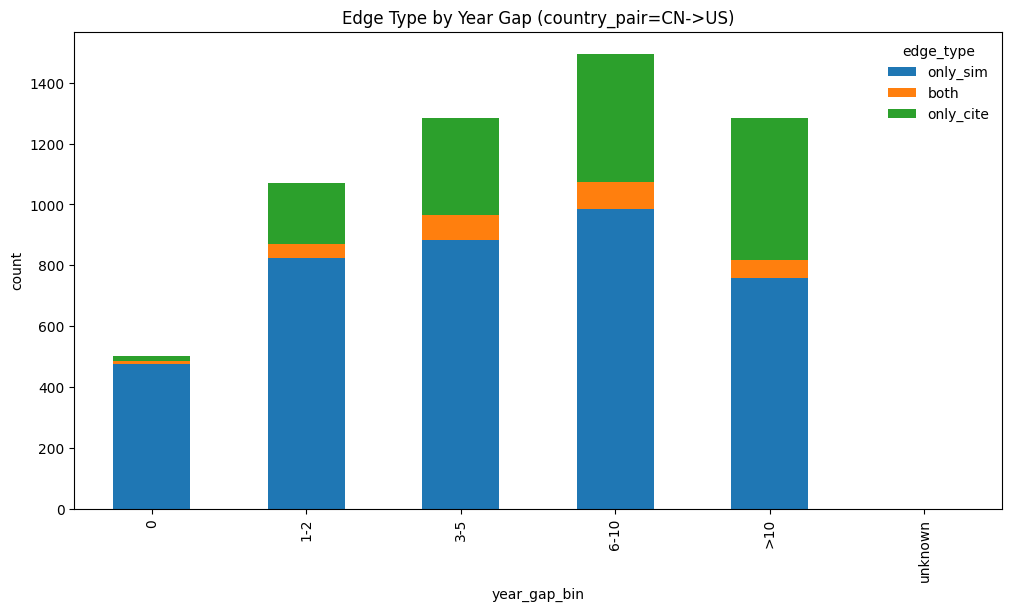

Saved: output/compare_networks/figs/edge_type_bucket_viz.png


In [30]:
# §10.3 Bucketed statistics + visualization

edge_frames = []
for _name, _df in [('only_sim', only_sim_df), ('both', both_df), ('only_cite', only_cite_df)]:
    xx = add_bucket_cols(_df)
    xx['edge_type'] = _name
    edge_frames.append(xx)

bucket_cols = ['edge_type', 'country_pair', 'year_gap_bin', 'same_topic']
if edge_frames:
    edge_all = pd.concat(edge_frames, ignore_index=True)
else:
    edge_all = pd.DataFrame(columns=bucket_cols + ['count'])

if len(edge_all) > 0:
    bucket_df = (
        edge_all
        .groupby(bucket_cols, dropna=False)
        .size()
        .reset_index(name='count')
    )
    denom_cp = bucket_df.groupby('country_pair')['count'].transform('sum').replace(0, np.nan)
    bucket_df['share_within_country_pair'] = bucket_df['count'] / denom_cp

    denom_cpg = bucket_df.groupby(['country_pair', 'year_gap_bin', 'same_topic'])['count'].transform('sum').replace(0, np.nan)
    bucket_df['share_within_country_pair_gap_topic'] = bucket_df['count'] / denom_cpg
else:
    bucket_df = pd.DataFrame(columns=bucket_cols + ['count', 'share_within_country_pair', 'share_within_country_pair_gap_topic'])

bucket_path = TABLES_DIR / 'edge_type_buckets.csv'
bucket_df.to_csv(bucket_path, index=False)
print(f'Saved: {bucket_path}')

# Figure: CN->US stacked bar over year-gap bins (fallback: top country_pair)
order_bins = ['0', '1-2', '3-5', '6-10', '>10', 'unknown']
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

if len(bucket_df) > 0:
    target_pair = 'CN->US' if (bucket_df['country_pair'] == 'CN->US').any() else bucket_df.groupby('country_pair')['count'].sum().sort_values(ascending=False).index[0]
    plot_df = bucket_df[bucket_df['country_pair'] == target_pair].copy()
    plot_df = plot_df.groupby(['year_gap_bin', 'edge_type'], as_index=False)['count'].sum()

    pivot = plot_df.pivot(index='year_gap_bin', columns='edge_type', values='count').fillna(0)
    pivot = pivot.reindex(order_bins).fillna(0)
    pivot = pivot[[c for c in ['only_sim', 'both', 'only_cite'] if c in pivot.columns]]

    if pivot.shape[1] > 0 and pivot.sum().sum() > 0:
        pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'Edge Type by Year Gap (country_pair={target_pair})')
        ax.set_xlabel('year_gap_bin')
        ax.set_ylabel('count')
        ax.legend(frameon=False, title='edge_type')
    else:
        ax.text(0.5, 0.5, 'No bucket data to plot', ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
else:
    ax.text(0.5, 0.5, 'No bucket data to plot', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

bucket_fig = FIGS_DIR / 'edge_type_bucket_viz.png'
fig.savefig(bucket_fig, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {bucket_fig}')


In [31]:
# §10.4 Qualitative sampling

sample_cols = ['edge_type', 'src_pid', 'dst_pid', 'year_src', 'year_dst', 'country_src', 'country_dst', 'topic_src', 'topic_dst', 'sim']

samples = []
for _etype, _df in [('only_sim', only_sim_df), ('both', both_df), ('only_cite', only_cite_df)]:
    x = add_bucket_cols(_df)
    s = stratified_sample(
        x,
        strata_cols=['country_pair', 'year_gap_bin', 'same_topic'],
        n_total=40,
        seed=SEED + {'only_sim': 1, 'both': 2, 'only_cite': 3}[_etype],
    )
    if len(s) > 0:
        s['edge_type'] = _etype
        if 'sim' not in s.columns:
            s['sim'] = np.nan
        samples.append(s)

if samples:
    qual_df = pd.concat(samples, ignore_index=True)
else:
    qual_df = pd.DataFrame(columns=sample_cols)

text_map = nodes_s10[['paper_id', 'title', 'abstract']].drop_duplicates('paper_id').copy()
text_map = text_map.rename(columns={'paper_id': 'pid'})
text_map['title'] = text_map['title'].fillna('').astype(str)
text_map['abstract'] = text_map['abstract'].fillna('').astype(str).str.slice(0, 200)

if len(qual_df) > 0:
    qual_df = qual_df.merge(
        text_map.rename(columns={'pid': 'src_pid', 'title': 'title_src', 'abstract': 'abstract_src'}),
        on='src_pid', how='left'
    )
    qual_df = qual_df.merge(
        text_map.rename(columns={'pid': 'dst_pid', 'title': 'title_dst', 'abstract': 'abstract_dst'}),
        on='dst_pid', how='left'
    )
else:
    qual_df['title_src'] = pd.Series(dtype='object')
    qual_df['title_dst'] = pd.Series(dtype='object')
    qual_df['abstract_src'] = pd.Series(dtype='object')
    qual_df['abstract_dst'] = pd.Series(dtype='object')

out_cols = [
    'edge_type', 'src_pid', 'dst_pid', 'year_src', 'year_dst', 'country_src', 'country_dst',
    'topic_src', 'topic_dst', 'sim', 'title_src', 'title_dst', 'abstract_src', 'abstract_dst'
]
for c in out_cols:
    if c not in qual_df.columns:
        qual_df[c] = np.nan

qual_df = qual_df[out_cols].copy()
qual_path = TABLES_DIR / 'qual_samples.csv'
qual_df.to_csv(qual_path, index=False)

print(f'§10.4 qual samples saved: {qual_path} | n={len(qual_df):,}')
print('sample by edge_type:', qual_df['edge_type'].value_counts(dropna=False).to_dict() if len(qual_df) else {})


§10.4 qual samples saved: output/compare_networks/tables/qual_samples.csv | n=120
sample by edge_type: {'only_sim': 40, 'both': 40, 'only_cite': 40}


In [32]:
# §10.5 Explainable citation probability model (Logistic Regression)

try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score, average_precision_score
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    SKLEARN_OK = True
except Exception as e:
    SKLEARN_OK = False
    print(f'[warn] sklearn unavailable: {e}')


def _sample_negatives_matched(neg_pool, pos_df, ratio=1, seed=42):
    if len(neg_pool) == 0 or len(pos_df) == 0:
        return neg_pool.iloc[:0].copy()

    rng = np.random.RandomState(seed)
    target_n = min(len(neg_pool), int(len(pos_df) * ratio))
    if target_n <= 0:
        return neg_pool.iloc[:0].copy()

    neg = neg_pool.copy().reset_index(drop=True)
    pos = pos_df.copy().reset_index(drop=True)

    for c in ['country_pair', 'year_gap_bin']:
        if c not in neg.columns:
            neg[c] = 'unknown'
        if c not in pos.columns:
            pos[c] = 'unknown'

    neg['_strata'] = neg['country_pair'].astype(str) + '|' + neg['year_gap_bin'].astype(str)
    pos['_strata'] = pos['country_pair'].astype(str) + '|' + pos['year_gap_bin'].astype(str)

    picks = []
    used = set()

    pos_counts = pos['_strata'].value_counts()
    for st, cnt in pos_counts.items():
        g = neg[neg['_strata'] == st]
        if len(g) == 0:
            continue
        want = max(1, int(round(target_n * cnt / max(1, len(pos)))))
        want = min(want, len(g))
        idx = g.sample(n=want, random_state=int(rng.randint(0, 1_000_000_000))).index.tolist()
        picks.extend(idx)
        used.update(idx)

    if len(picks) < target_n:
        remain = neg.loc[~neg.index.isin(used)].copy()
        remain['_cp'] = remain['country_pair'].astype(str)
        pos_cp_counts = pos['country_pair'].astype(str).value_counts()
        for cp, cnt in pos_cp_counts.items():
            if len(picks) >= target_n:
                break
            g = remain[remain['_cp'] == cp]
            if len(g) == 0:
                continue
            want = max(1, int(round(target_n * cnt / max(1, len(pos)))))
            want = min(want, len(g), target_n - len(picks))
            idx = g.sample(n=want, random_state=int(rng.randint(0, 1_000_000_000))).index.tolist()
            picks.extend(idx)
            remain = remain.loc[~remain.index.isin(idx)]

    if len(picks) < target_n:
        remain = neg.loc[~neg.index.isin(pd.Index(picks).drop_duplicates())]
        need = min(target_n - len(picks), len(remain))
        if need > 0:
            idx = remain.sample(n=need, random_state=int(rng.randint(0, 1_000_000_000))).index.tolist()
            picks.extend(idx)

    picks = list(pd.Index(picks).drop_duplicates())
    if len(picks) > target_n:
        picks = list(pd.Series(picks).sample(n=target_n, random_state=int(rng.randint(0, 1_000_000_000))).tolist())

    return neg.loc[picks].copy().reset_index(drop=True)


pos_df = add_bucket_cols(both_df)
neg_pool = add_bucket_cols(only_sim_df)
neg_df = _sample_negatives_matched(neg_pool, pos_df, ratio=1, seed=SEED)

if len(pos_df) == 0 or len(neg_df) == 0:
    print('[warn] insufficient both/only_sim edges for modeling; writing empty outputs')
    coef_df = pd.DataFrame(columns=['feature', 'coef', 'odds_ratio', 'abs_coef'])
    metrics_df = pd.DataFrame(columns=['metric', 'value'])
else:
    pos_use = pos_df.copy()
    pos_use['label'] = 1
    neg_use = neg_df.copy()
    neg_use['label'] = 0
    model_df = pd.concat([pos_use, neg_use], ignore_index=True)

    model_df['sim'] = pd.to_numeric(model_df['sim'], errors='coerce').fillna(0.0)
    model_df['year_gap'] = pd.to_numeric(model_df['year_gap'], errors='coerce')
    if model_df['year_gap'].isna().all():
        model_df['year_gap'] = 0.0
    else:
        model_df['year_gap'] = model_df['year_gap'].fillna(model_df['year_gap'].median())

    model_df['same_topic'] = model_df['same_topic'].fillna(False).astype(int)
    model_df['country_pair'] = model_df['country_pair'].fillna('OTHER->OTHER').astype(str)
    model_df['is_cn_us'] = (model_df['country_pair'] == 'CN->US').astype(int)
    model_df['is_us_cn'] = (model_df['country_pair'] == 'US->CN').astype(int)

    scaler = StandardScaler()
    scaled = scaler.fit_transform(model_df[['sim', 'year_gap']])
    model_df['sim_z'] = scaled[:, 0]
    model_df['year_gap_z'] = scaled[:, 1]

    model_df['sim_x_cn_us'] = model_df['sim_z'] * model_df['is_cn_us']
    model_df['sim_x_us_cn'] = model_df['sim_z'] * model_df['is_us_cn']

    feat_cols = ['sim_z', 'year_gap_z', 'same_topic', 'is_cn_us', 'is_us_cn', 'sim_x_cn_us', 'sim_x_us_cn']
    X = model_df[feat_cols].copy()
    y = model_df['label'].astype(int)

    if SKLEARN_OK and y.nunique() >= 2 and len(model_df) >= 20:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=SEED, stratify=y
        )
        clf = LogisticRegression(max_iter=2000, C=1.0, class_weight='balanced', random_state=SEED)
        clf.fit(X_train, y_train)

        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = float(roc_auc_score(y_test, y_prob)) if y_test.nunique() > 1 else np.nan
        ap = float(average_precision_score(y_test, y_prob)) if y_test.nunique() > 1 else np.nan

        coef_df = pd.DataFrame({
            'feature': feat_cols,
            'coef': clf.coef_[0],
        })
        coef_df['odds_ratio'] = np.exp(coef_df['coef'])
        coef_df['abs_coef'] = coef_df['coef'].abs()

        metrics_df = pd.DataFrame([
            {'metric': 'n_samples', 'value': float(len(model_df))},
            {'metric': 'n_pos', 'value': float(int(y.sum()))},
            {'metric': 'n_neg', 'value': float(int((1 - y).sum()))},
            {'metric': 'auc', 'value': auc},
            {'metric': 'average_precision', 'value': ap},
        ])
        print('[§10.5] model metrics:', metrics_df.set_index('metric')['value'].to_dict())
    else:
        print('[warn] sklearn unavailable or data insufficient for train/test; writing empty model outputs')
        coef_df = pd.DataFrame(columns=['feature', 'coef', 'odds_ratio', 'abs_coef'])
        metrics_df = pd.DataFrame([
            {'metric': 'n_samples', 'value': float(len(model_df))},
            {'metric': 'n_pos', 'value': float(int(y.sum()))},
            {'metric': 'n_neg', 'value': float(int((1 - y).sum()))},
        ])

coef_path = TABLES_DIR / 'logit_coef.csv'
coef_df.to_csv(coef_path, index=False)
metrics_path = TABLES_DIR / 'logit_metrics.csv'
metrics_df.to_csv(metrics_path, index=False)
print(f'Saved: {coef_path}')
print(f'Saved: {metrics_path}')


[§10.5] model metrics: {'n_samples': 29084.0, 'n_pos': 14542.0, 'n_neg': 14542.0, 'auc': 0.6915471384873486, 'average_precision': 0.6924294201872538}
Saved: output/compare_networks/tables/logit_coef.csv
Saved: output/compare_networks/tables/logit_metrics.csv


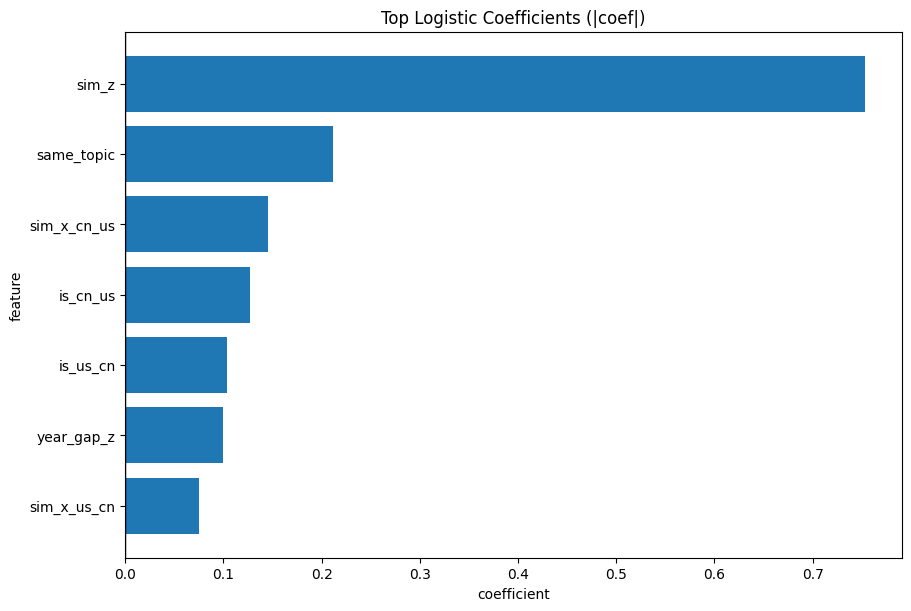

Saved: output/compare_networks/figs/logit_coef.png
### §10.5 Logistic Interpretation
- sim 主效应 (z-score): beta=0.7530, OR=2.1233
- sim × I(CN->US): beta=0.1457 -> CN->US 有效 sim 斜率=0.8987, OR=2.4564
- sim × I(US->CN): beta=0.0746 -> US->CN 有效 sim 斜率=0.8276, OR=2.2878


In [33]:
# §10.5 Coefficient interpretation + visualization

if 'coef_df' not in globals() or not isinstance(coef_df, pd.DataFrame):
    coef_path = TABLES_DIR / 'logit_coef.csv'
    coef_df = pd.read_csv(coef_path) if coef_path.exists() else pd.DataFrame(columns=['feature', 'coef', 'odds_ratio', 'abs_coef'])

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
if len(coef_df) > 0 and 'abs_coef' in coef_df.columns:
    top = coef_df.sort_values('abs_coef', ascending=False).head(10).copy()
    top = top.sort_values('coef', ascending=True)
    colors = ['#d62728' if v < 0 else '#1f77b4' for v in top['coef']]
    ax.barh(top['feature'], top['coef'], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_title('Top Logistic Coefficients (|coef|)')
    ax.set_xlabel('coefficient')
    ax.set_ylabel('feature')
else:
    ax.text(0.5, 0.5, 'No coefficient data', ha='center', va='center', transform=ax.transAxes)
    ax.set_axis_off()

coef_fig = FIGS_DIR / 'logit_coef.png'
fig.savefig(coef_fig, dpi=180, bbox_inches='tight')
plt.show()
print(f'Saved: {coef_fig}')


def _beta(name, default=np.nan):
    if len(coef_df) == 0 or name not in set(coef_df['feature'].astype(str)):
        return default
    return float(coef_df.loc[coef_df['feature'] == name, 'coef'].iloc[0])

beta_sim = _beta('sim_z')
beta_cnus = _beta('sim_x_cn_us', 0.0)
beta_uscn = _beta('sim_x_us_cn', 0.0)

beta_sim_cn_us = beta_sim + beta_cnus if pd.notna(beta_sim) else np.nan
beta_sim_us_cn = beta_sim + beta_uscn if pd.notna(beta_sim) else np.nan

print('### §10.5 Logistic Interpretation')
if pd.notna(beta_sim):
    print(f'- sim 主效应 (z-score): beta={beta_sim:.4f}, OR={np.exp(beta_sim):.4f}')
    print(f'- sim × I(CN->US): beta={beta_cnus:.4f} -> CN->US 有效 sim 斜率={beta_sim_cn_us:.4f}, OR={np.exp(beta_sim_cn_us):.4f}')
    print(f'- sim × I(US->CN): beta={beta_uscn:.4f} -> US->CN 有效 sim 斜率={beta_sim_us_cn:.4f}, OR={np.exp(beta_sim_us_cn):.4f}')
else:
    print('- 系数不可用（样本不足或模型未成功拟合）。')


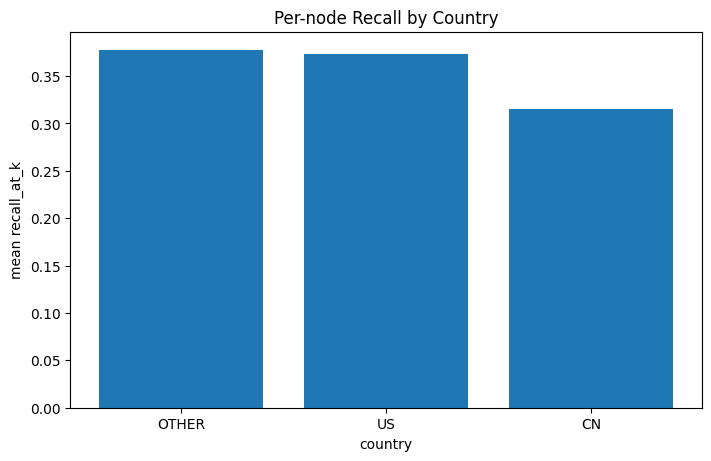

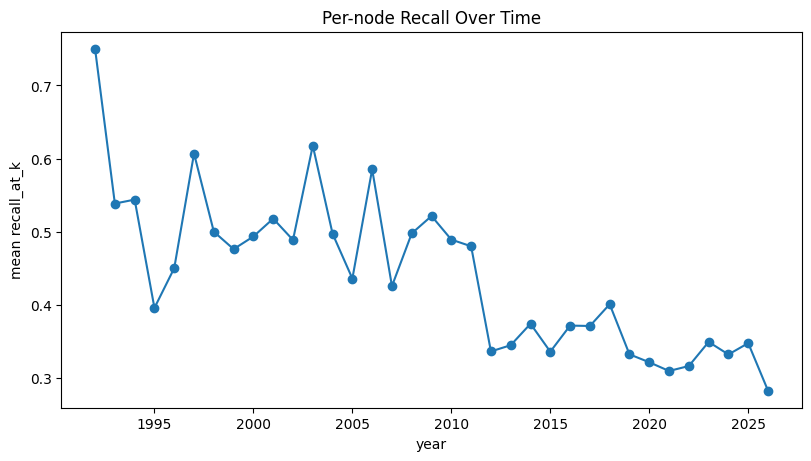

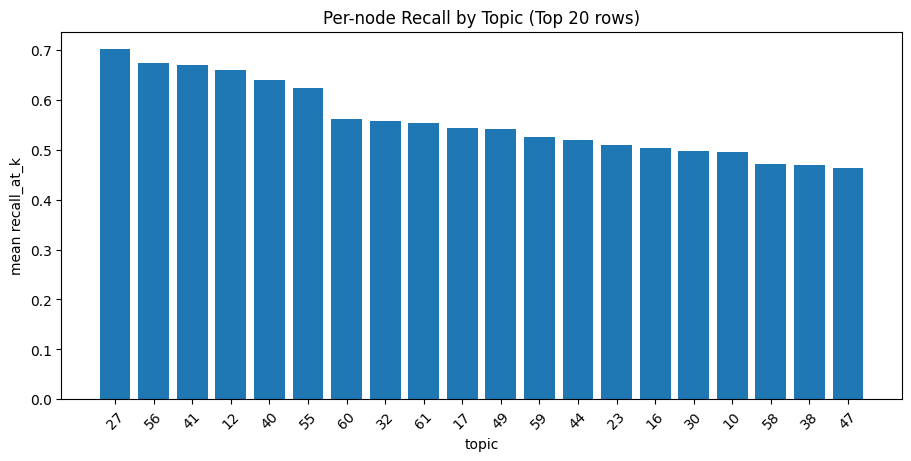

Saved: output/compare_networks/tables/per_node_recall_by_country.csv
Saved: output/compare_networks/tables/per_node_recall_by_year.csv
Saved: output/compare_networks/tables/per_node_recall_by_topic.csv
Saved: output/compare_networks/figs/recall_by_country.png
Saved: output/compare_networks/figs/recall_over_time.png
Saved: output/compare_networks/figs/recall_by_topic.png


In [34]:
# §10.6 Use per_node_recall_time

per_node_path = TABLES_DIR / 'per_node_recall_time.csv'
if per_node_path.exists():
    pr = pd.read_csv(per_node_path)

    if 'recall_at_k' not in pr.columns:
        print(f'[warn] {per_node_path} missing recall_at_k column; skip')
    else:
        pr['recall_at_k'] = pd.to_numeric(pr['recall_at_k'], errors='coerce')

        if 'country' in pr.columns:
            pr['country_norm'] = pr['country'].map(normalize_country)
        elif 'country2' in pr.columns:
            pr['country_norm'] = pr['country2'].map(normalize_country)
        else:
            pr['country_norm'] = 'OTHER'

        if 'year_src_meta' in pr.columns:
            pr['year_for_group'] = pd.to_numeric(pr['year_src_meta'], errors='coerce')
        elif 'year_src' in pr.columns:
            pr['year_for_group'] = pd.to_numeric(pr['year_src'], errors='coerce')
        else:
            pr['year_for_group'] = np.nan

        if 'topic' in pr.columns:
            pr['topic_for_group'] = pd.to_numeric(pr['topic'], errors='coerce').fillna(-1).astype(int)
        else:
            pr['topic_for_group'] = -1

        by_country = pr.groupby('country_norm', dropna=False).agg(
            n_src=('src_pid', 'nunique'),
            mean_recall=('recall_at_k', 'mean'),
            median_recall=('recall_at_k', 'median'),
        ).reset_index().sort_values('mean_recall', ascending=False)

        by_year = pr.groupby('year_for_group', dropna=False).agg(
            n_src=('src_pid', 'nunique'),
            mean_recall=('recall_at_k', 'mean'),
            median_recall=('recall_at_k', 'median'),
        ).reset_index().sort_values('year_for_group')

        by_topic = pr.groupby('topic_for_group', dropna=False).agg(
            n_src=('src_pid', 'nunique'),
            mean_recall=('recall_at_k', 'mean'),
            median_recall=('recall_at_k', 'median'),
        ).reset_index().sort_values('mean_recall', ascending=False)

        p_country = TABLES_DIR / 'per_node_recall_by_country.csv'
        p_year = TABLES_DIR / 'per_node_recall_by_year.csv'
        p_topic = TABLES_DIR / 'per_node_recall_by_topic.csv'
        by_country.to_csv(p_country, index=False)
        by_year.to_csv(p_year, index=False)
        by_topic.to_csv(p_topic, index=False)

        # recall_by_country
        fig, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
        if len(by_country) > 0:
            ax.bar(by_country['country_norm'].astype(str), by_country['mean_recall'])
            ax.set_title('Per-node Recall by Country')
            ax.set_xlabel('country')
            ax.set_ylabel('mean recall_at_k')
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        fig_country = FIGS_DIR / 'recall_by_country.png'
        fig.savefig(fig_country, dpi=180, bbox_inches='tight')
        plt.show()

        # recall_over_time
        fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
        yy = by_year.dropna(subset=['year_for_group']).copy()
        if len(yy) > 0:
            yy['year_for_group'] = yy['year_for_group'].astype(int)
            ax.plot(yy['year_for_group'], yy['mean_recall'], marker='o')
            ax.set_title('Per-node Recall Over Time')
            ax.set_xlabel('year')
            ax.set_ylabel('mean recall_at_k')
        else:
            ax.text(0.5, 0.5, 'No year data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        fig_year = FIGS_DIR / 'recall_over_time.png'
        fig.savefig(fig_year, dpi=180, bbox_inches='tight')
        plt.show()

        # recall_by_topic
        fig, ax = plt.subplots(figsize=(9, 4.5), constrained_layout=True)
        tt = by_topic.head(20).copy()
        if len(tt) > 0:
            ax.bar(tt['topic_for_group'].astype(str), tt['mean_recall'])
            ax.set_title('Per-node Recall by Topic (Top 20 rows)')
            ax.set_xlabel('topic')
            ax.set_ylabel('mean recall_at_k')
            ax.tick_params(axis='x', rotation=45)
        else:
            ax.text(0.5, 0.5, 'No topic data', ha='center', va='center', transform=ax.transAxes)
            ax.set_axis_off()
        fig_topic = FIGS_DIR / 'recall_by_topic.png'
        fig.savefig(fig_topic, dpi=180, bbox_inches='tight')
        plt.show()

        print('Saved:', p_country)
        print('Saved:', p_year)
        print('Saved:', p_topic)
        print('Saved:', fig_country)
        print('Saved:', fig_year)
        print('Saved:', fig_topic)
else:
    print(f'[skip] {per_node_path} not found; §10.6 skipped')
